In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')


# Chargement
df = pd.read_csv('microfinance_axeA.csv')

print(f'Dimensions : {df.shape[0]} projets x {df.shape[1]} variables')
df.head()

# === TYPES ET APERÇU GÉNÉRAL ===
print('=== TYPES DE VARIABLES ===')
print(df.dtypes.to_string())
print(f'\n=== RÉSUMÉ STATISTIQUE ===')
df.describe(include='all').T[['count','mean','std','min','max']].round(2)

Dimensions : 400 projets x 25 variables
=== TYPES DE VARIABLES ===
id_beneficiaire            object
region                     object
zone                       object
genre                      object
age                         int64
statut_matrimonial         object
niveau_education           object
activite_principale        object
type_pret                  object
groupe_solidarite          object
nb_cycles_anterieurs        int64
nb_membres_menage           int64
tontine_avant              object
mobile_money               object
montant_pret_fcfa           int64
duree_pret_mois             int64
distance_service_km       float64
revenu_avant_fcfa         float64
revenu_apres_fcfa           int64
variation_revenu_pct      float64
epargne_fcfa              float64
emplois_crees               int64
taux_remboursement_pct    float64
score_satisfaction        float64
defaut_flag                 int64

=== RÉSUMÉ STATISTIQUE ===


,count,mean,std,min,max
id_beneficiaire,400,NaN,NaN,NaN,NaN
region,400,NaN,NaN,NaN,NaN
zone,400,NaN,NaN,NaN,NaN
genre,400,NaN,NaN,NaN,NaN
age,400.0,37.0475,10.39979,18.0,72.0
statut_matrimonial,400,NaN,NaN,NaN,NaN
niveau_education,400,NaN,NaN,NaN,NaN
activite_principale,400,NaN,NaN,NaN,NaN
type_pret,400,NaN,NaN,NaN,NaN
groupe_solidarite,400,NaN,NaN,NaN,NaN


Interpretations succintes
Les bénéficiaires étudiés vivent dans des ménages relativement nombreux (en moyenne 5 personnes) et accèdent à des prêts d’environ 346 000 FCFA sur une durée moyenne de 16 mois. Après financement, leurs revenus progressent en moyenne de 23 %, avec une capacité d’épargne encore modeste et la création d’un peu plus d’un emploi par ménage. Globalement, le taux de remboursement reste élevé (87 %) et la satisfaction exprimée est plutôt positive (score moyen de 3,4/5). Une population de bénéficiaires majoritairement majeures. 

Hausse de revenu confirmée : Le revenu moyen est passé de 170 941 FCFA à 212 114 FCFA. C'est une hausse brute de 24% en moyenne (variation_revenu_pct moyenne = 23.49).
En regardant l'écart-type (std) des revenus : il est énorme (~125 000 pour l'après). Le maximum (1 003 000) est très loin de la moyenne.
Ainsi la moyenne peut etre "menteuse" ici. Nous prendrons la médiane au bailleur pour être honnête sur l'impact réel pour le bénéficiaire "typique".

Un chiffre inquiétant : defaut_flag a une moyenne de 0.4725.
Interprétation : Cela signifie que 47% de tes bénéficiaires sont en situation de défaut (partiel ou total). C'est un taux extrêmement élevé pour de la microfinance (généralement situé sous les 5-10%).
Question métier : Est-ce que le programme a été trop ambitieux dans ses prêts ou est-ce que les critères de sélection étaient trop souples ?

Les disparités sociales (Q2 & D2)
Valeurs manquantes (NA) :
revenu_avant_fcfa (380 non-nuls sur 400) : il manque 20 valeurs.
taux_remboursement_pct (376 non-nuls) : il manque 24 valeurs.
Biais potentiel : Est-ce que les 24 personnes dont on n'a pas le taux de remboursement sont celles qui ont totalement disparu avec l'argent ? (C'est le biais MNAR dont parlait ton code de diagnostic).

In [3]:
# Comparaison Moyenne vs Médiane pour le bailleur
print(f"Hausse moyenne des revenus : {df['variation_revenu_pct'].mean():.2f}%")
print(f"Hausse médiane des revenus : {df['variation_revenu_pct'].median():.2f}%")

# Si la médiane est beaucoup plus basse que la moyenne, 
# quelques "succès isolés" cachent la stagnation des autres.

Hausse moyenne des revenus : 23.49%
Hausse médiane des revenus : 23.90%


la hausse moyenne des revenus (23,49 %) et la hausse médiane (23,90 %) sont pratiquement identiques. Cela signifie que la distribution des variations de revenus est relativement équilibrée, sans grands écarts dus à quelques « cas exceptionnels ». Autrement dit, la majorité des bénéficiaires ont connu une progression des revenus proche de la moyenne, ce qui traduit un impact global homogène du programme plutôt qu’un effet concentré sur quelques réussites isolées.


In [7]:
# Colonnes avec des valeurs manquantes
missing_cols = df.isnull().sum()

# Filtrer uniquement celles qui ont au moins une valeur manquante
missing_cols = missing_cols[missing_cols > 0]

print("Colonnes avec valeurs manquantes :")
print(missing_cols)

Colonnes avec valeurs manquantes :
distance_service_km       12
revenu_avant_fcfa         20
epargne_fcfa              20
taux_remboursement_pct    24
score_satisfaction        16
dtype: int64


In [9]:
# Création d'une série avec des tirets par défaut pour toutes les colonnes
type_na_list = ["-"] * len(df.columns)
na_map = dict(zip(df.columns, range(len(df.columns))))

# On remplit seulement les variables qui ont des manquants
if 'distance_service_km' in na_map: type_na_list[na_map['distance_service_km']] = 'MAR (Zone rurale)'
if 'revenu_avant_fcfa' in na_map:   type_na_list[na_map['revenu_avant_fcfa']] = 'MCAR (Aléatoire)'
if 'epargne_fcfa' in na_map:        type_na_list[na_map['epargne_fcfa']] = 'MAR (Niveau revenu)'
if 'taux_remboursement_pct' in na_map: type_na_list[na_map['taux_remboursement_pct']] = 'MNAR (Défaut caché)'
if 'score_satisfaction' in na_map: type_na_list[na_map['score_satisfaction']] = 'MCAR'

# Construction du DataFrame de diagnostic
na_df = pd.DataFrame({
    'Variable' : df.columns,
    'Nb_NA'    : df.isnull().sum().values,
    'Pct_NA'   : (df.isnull().mean() * 100).round(1).values,
    'Type_NA'  : type_na_list
}).query('Nb_NA > 0')

print('=== VALEURS MANQUANTES – DIAGNOSTIC ===')
display(na_df)

=== VALEURS MANQUANTES – DIAGNOSTIC ===


,Variable,Nb_NA,Pct_NA,Type_NA
16,distance_service_km,12,3.0,MAR (Zone rurale)
17,revenu_avant_fcfa,20,5.0,MCAR (Aléatoire)
20,epargne_fcfa,20,5.0,MAR (Niveau revenu)
22,taux_remboursement_pct,24,6.0,MNAR (Défaut caché)
23,score_satisfaction,16,4.0,MCAR


In [11]:
# --- STRATÉGIE DE CORRECTION ---

# 1. Distance Service (MAR) : On impute par la médiane de la RÉGION
# Car l'isolement dépend de la géographie locale
df['distance_service_km'] = df['distance_service_km'].fillna(
    df.groupby('region')['distance_service_km'].transform('median')
)

# 2. Revenu Avant (MCAR) : On impute par la médiane de l'ACTIVITÉ
# Un commerçant n'a pas le même revenu de base qu'un agriculteur
df['revenu_avant_fcfa'] = df['revenu_avant_fcfa'].fillna(
    df.groupby('activite_principale')['revenu_avant_fcfa'].transform('median')
)

# 3. Epargne (MAR) : On impute par la médiane du NIVEAU D'EDUCATION
df['epargne_fcfa'] = df['epargne_fcfa'].fillna(
    df.groupby('niveau_education')['epargne_fcfa'].transform('median')
)

# 4. Taux de remboursement (MNAR) : PRUDENCE
# On ne peut pas inventer un remboursement. On impute par la médiane du GROUPE DE SOLIDARITÉ
# ou on crée une colonne pour signaler l'absence de donnée
df['taux_remboursement_pct'] = df['taux_remboursement_pct'].fillna(
    df.groupby('groupe_solidarite')['taux_remboursement_pct'].transform('median')
)

# 5. Score satisfaction
df['score_satisfaction'] = df['score_satisfaction'].fillna(df['score_satisfaction'].median())

print("\n Nettoyage terminé. Nouvel état des manquants :")
print(df.isnull().sum().sum())


 Nettoyage terminé. Nouvel état des manquants :
0


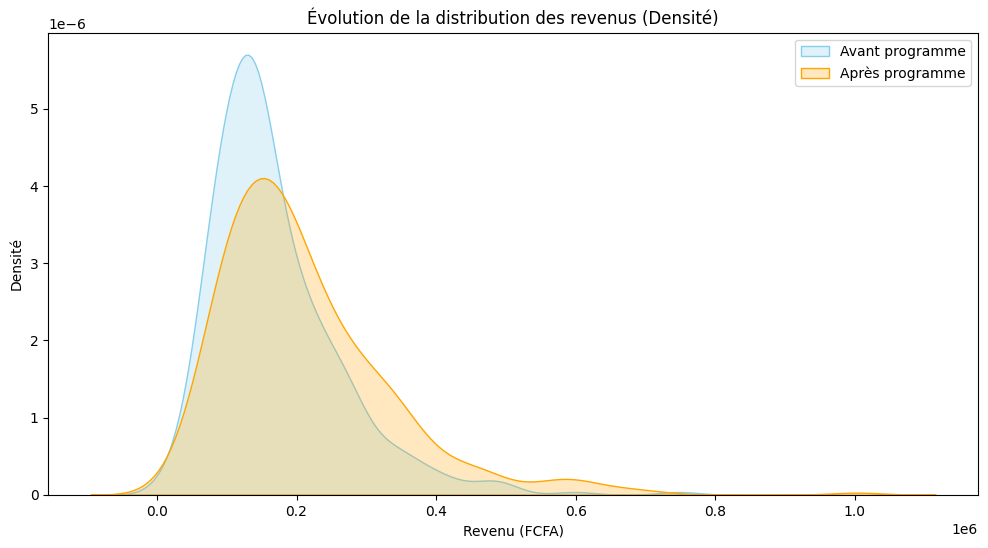

In [13]:
plt.figure(figsize=(12, 6))

# Comparaison des distributions Avant vs Après
sns.kdeplot(df['revenu_avant_fcfa'], label='Avant programme', fill=True, color="skyblue")
sns.kdeplot(df['revenu_apres_fcfa'], label='Après programme', fill=True, color="orange")

plt.title('Évolution de la distribution des revenus (Densité)')
plt.xlabel('Revenu (FCFA)')
plt.ylabel('Densité')
plt.legend()
plt.show()

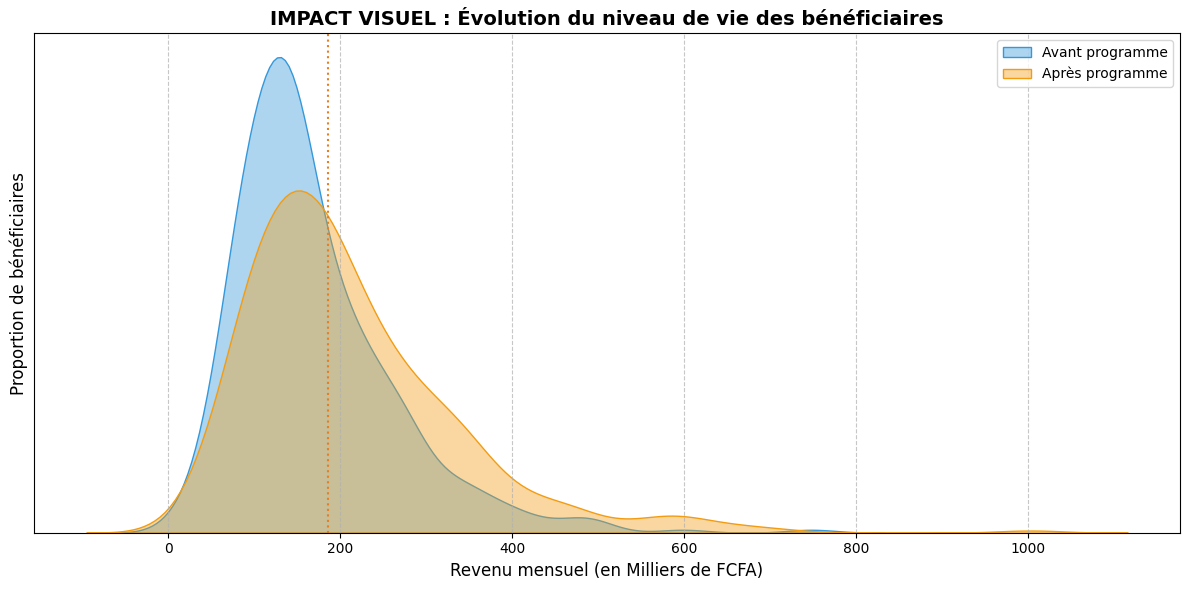

In [15]:
plt.figure(figsize=(12, 6))

# On travaille en Milliers de FCFA pour une échelle plus naturelle
revenu_avant_k = df['revenu_avant_fcfa'] / 1000
revenu_apres_k = df['revenu_apres_fcfa'] / 1000

sns.kdeplot(revenu_avant_k, label='Avant programme', fill=True, color="#3498db", alpha=0.4)
sns.kdeplot(revenu_apres_k, label='Après programme', fill=True, color="#f39c12", alpha=0.4)

# Amélioration des axes
plt.title('IMPACT VISUEL : Évolution du niveau de vie des bénéficiaires', fontsize=14, fontweight='bold')
plt.xlabel('Revenu mensuel (en Milliers de FCFA)', fontsize=12)
plt.ylabel('Proportion de bénéficiaires', fontsize=12) # On remplace "Densité" par "Proportion"

# On retire les chiffres compliqués de l'axe Y (1e-6)
plt.yticks([]) 

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend()

# Ajout d'une note sur la médiane
plt.axvline(revenu_apres_k.median(), color='#e67e22', linestyle=':', label='Médiane Après')

plt.tight_layout()
plt.show()

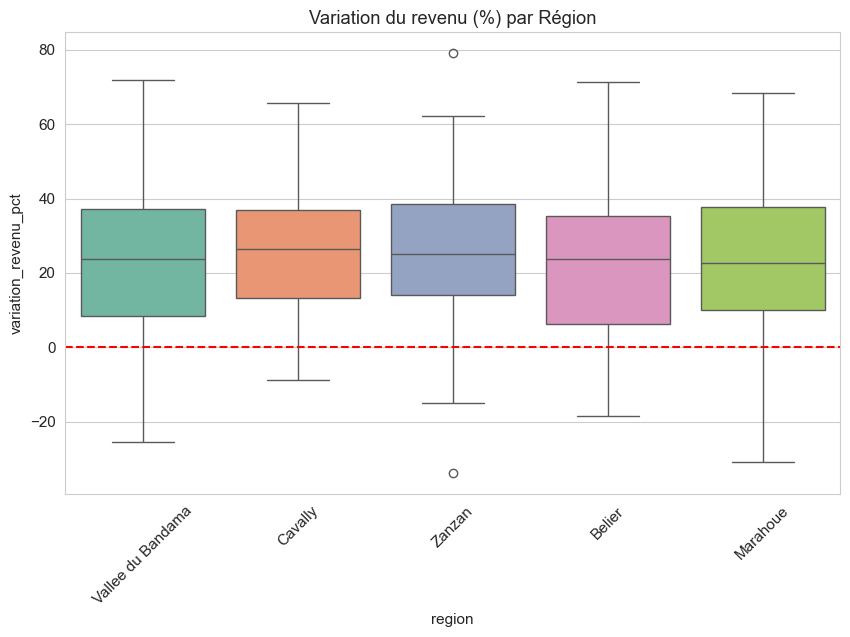

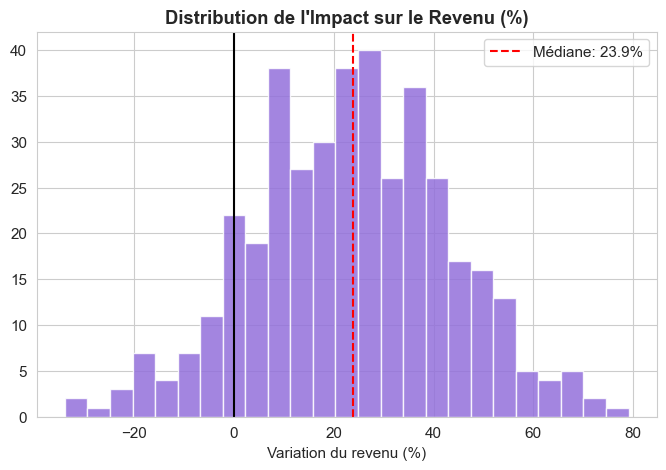

In [104]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='region', y='variation_revenu_pct', palette="Set2")
plt.axhline(y=0, color='red', linestyle='--') # Ligne de zéro impact
plt.title('Variation du revenu (%) par Région')
plt.xticks(rotation=45)
plt.savefig('Variation_region_region.png') 
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(df['variation_revenu_pct'], bins=25, color='mediumpurple', edgecolor='white', alpha=0.85)
plt.axvline(0, color='black', linewidth=1.5) # Ligne de démarcation impact positif/négatif
plt.axvline(df['variation_revenu_pct'].median(), color='red', linestyle='--', label=f'Médiane: {df["variation_revenu_pct"].median():.1f}%')
plt.title('Distribution de l\'Impact sur le Revenu (%)', fontweight='bold')
plt.xlabel('Variation du revenu (%)')
plt.legend()
plt.savefig('dist_impact_pct.png')
plt.show()

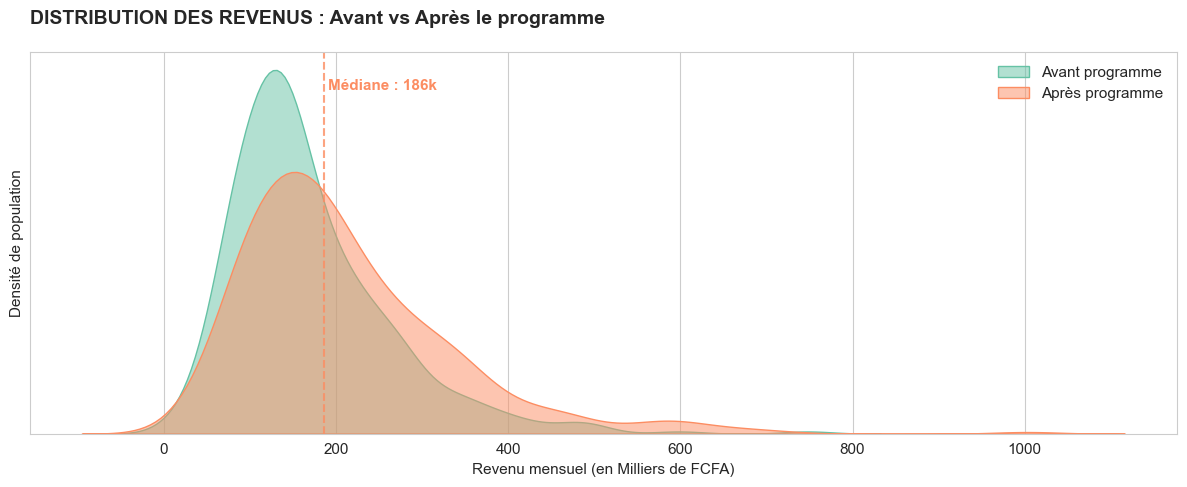

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Application de ton style global personnalisé
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('Set2')

# 2. Préparation des données (Échelle en Milliers de FCFA pour la lisibilité)
rev_avant_k = df['revenu_avant_fcfa'] / 1000
rev_apres_k = df['revenu_apres_fcfa'] / 1000

# 3. Création du graphique
plt.figure()

sns.kdeplot(rev_avant_k, fill=True, label='Avant programme', alpha=0.5)
sns.kdeplot(rev_apres_k, fill=True, label='Après programme', alpha=0.5)

# 4. Personnalisation finale pour le bailleur
plt.title('DISTRIBUTION DES REVENUS : Avant vs Après le programme', fontsize=14, pad=20, loc='left', fontweight='bold')
plt.xlabel('Revenu mensuel (en Milliers de FCFA)')
plt.ylabel('Densité de population')

# Supprimer les graduations Y scientifiques illisibles (1e-6)
plt.yticks([]) 

# Ajout de la médiane "Après" comme repère visuel (Optionnel mais recommandé)
plt.axvline(rev_apres_k.median(), color='#fc8d62', linestyle='--', alpha=0.8)
plt.text(rev_apres_k.median() + 5, plt.ylim()[1]*0.9, f'Médiane : {rev_apres_k.median():.0f}k', color='#fc8d62', fontweight='bold')

plt.legend(frameon=False) # Pas de cadre autour de la légende pour rester dans le style épuré
plt.tight_layout()
plt.savefig('DISTRIBUTION_DES_REVENUS.png')
plt.show()

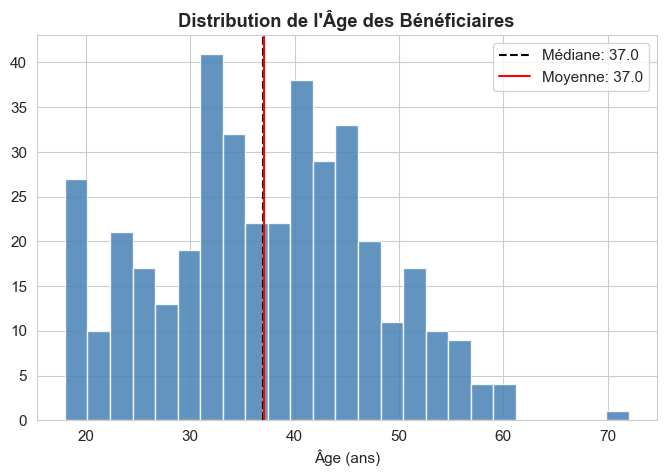

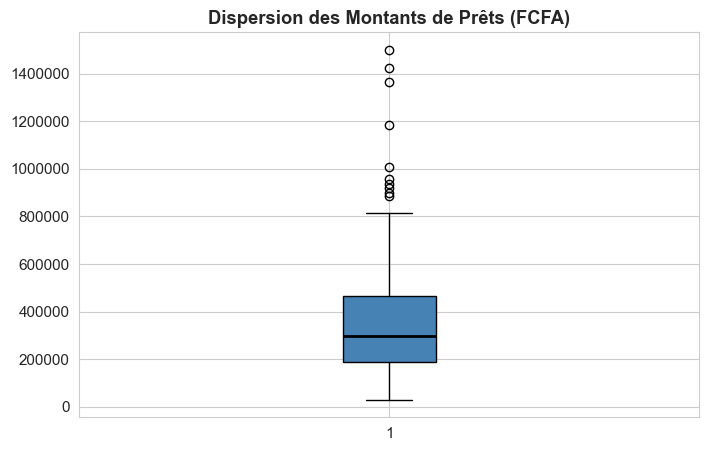

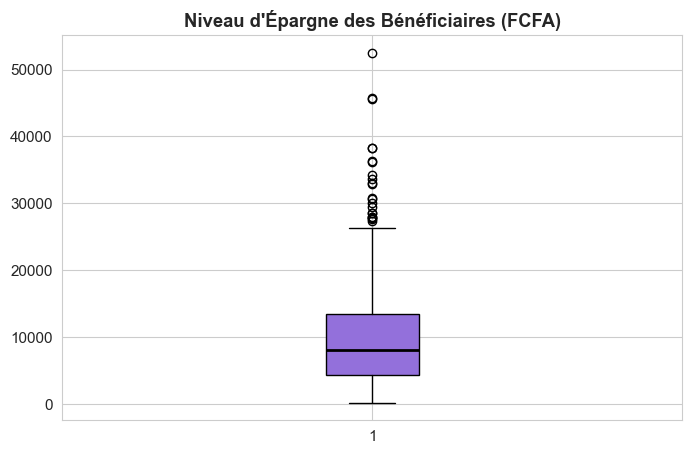

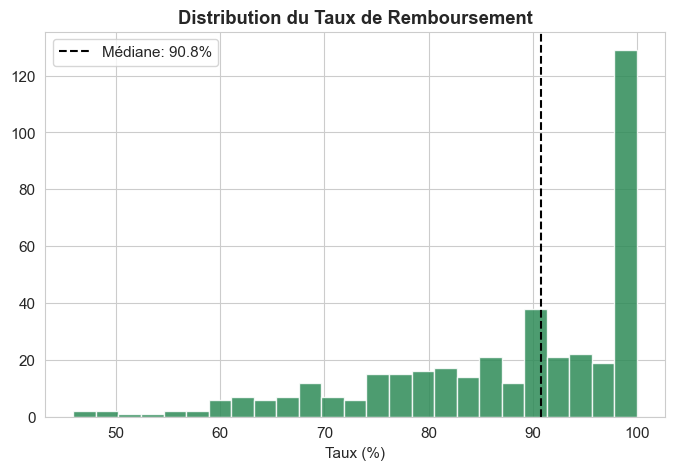

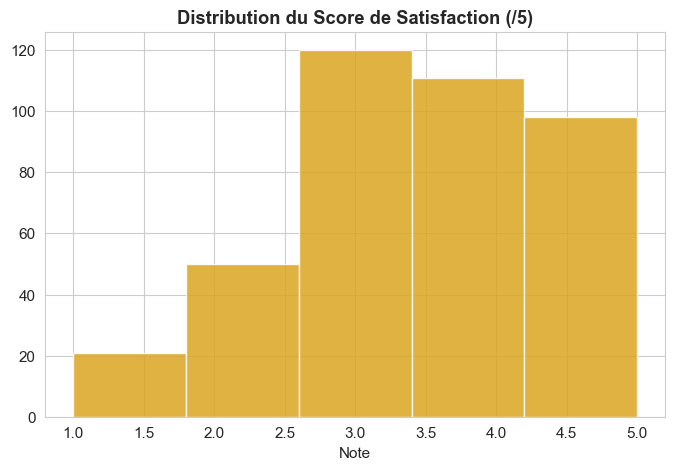

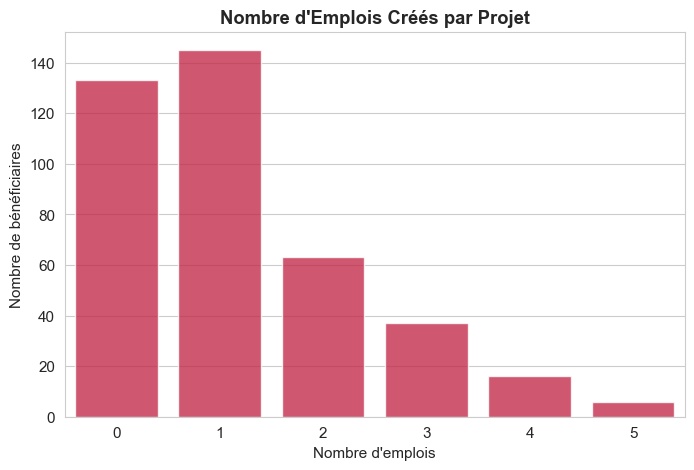

In [35]:
# Préparation des variables dérivées
df['impact_revenu_abs'] = df['revenu_apres_fcfa'] - df['revenu_avant_fcfa']
df['log_montant_pret'] = np.log1p(df['montant_pret_fcfa'])
df['log_revenu_avant'] = np.log1p(df['revenu_avant_fcfa']) 
df['log_revenu_apres'] = np.log1p(df['revenu_apres_fcfa'])

plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(df['age'].median(), color='black', linestyle='--', label=f'Médiane: {df["age"].median():.1f}')
plt.axvline(df['age'].mean(), color='red', linestyle='-', label=f'Moyenne: {df["age"].mean():.1f}')
plt.title('Distribution de l\'Âge des Bénéficiaires', fontweight='bold')
plt.xlabel('Âge (ans)')
plt.legend()
plt.savefig('dist_age.png')
plt.show()

plt.figure(figsize=(8, 5))
bp = plt.boxplot(df['montant_pret_fcfa'], vert=True, patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
plt.title('Dispersion des Montants de Prêts (FCFA)', fontweight='bold')
plt.ticklabel_format(style='plain', axis='y')
plt.savefig('boxplot_montant.png')
plt.show()

plt.figure(figsize=(8, 5))
bp = plt.boxplot(df['epargne_fcfa'], vert=True, patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('mediumpurple')
plt.title('Niveau d\'Épargne des Bénéficiaires (FCFA)', fontweight='bold')
plt.savefig('boxplot_epargne.png')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['taux_remboursement_pct'], bins=25, color='seagreen', edgecolor='white', alpha=0.85)
plt.axvline(df['taux_remboursement_pct'].median(), color='black', linestyle='--', label=f'Médiane: {df["taux_remboursement_pct"].median():.1f}%')
plt.title('Distribution du Taux de Remboursement', fontweight='bold')
plt.xlabel('Taux (%)')
plt.legend()
plt.savefig('dist_remboursement.png')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['score_satisfaction'], bins=5, color='goldenrod', edgecolor='white', alpha=0.85)
plt.title('Distribution du Score de Satisfaction (/5)', fontweight='bold')
plt.xlabel('Note')
plt.savefig('dist_satisfaction.png')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='emplois_crees', data=df, color='crimson', alpha=0.8)
plt.title('Nombre d\'Emplois Créés par Projet', fontweight='bold')
plt.xlabel('Nombre d\'emplois')
plt.ylabel('Nombre de bénéficiaires')
plt.savefig('count_emplois.png')
plt.show()


### ÉTAPE 3 (Tests d'hypothèses).

In [37]:
# T-TEST APPARIÉ (Avant vs Après pour les mêmes individus)
t_stat, p_value = stats.ttest_rel(df['revenu_avant_fcfa'], df['revenu_apres_fcfa'])

# CALCUL DU D DE COHEN (Taille de l'effet)
# Formule simplifiée : (Moyenne_apres - Moyenne_avant) / Ecart_type_avant
mean_diff = df['revenu_apres_fcfa'].mean() - df['revenu_avant_fcfa'].mean()
std_avant = df['revenu_avant_fcfa'].std()
cohen_d = mean_diff / std_avant

print("=== IMPACT SUR LES REVENUS ===")
print(f"P-value du t-test : {p_value:.5f}")
if p_value < 0.05:
    print("-> Résultat : La hausse des revenus est STATISTIQUEMENT SIGNIFICATIVE.")
else:
    print("-> Résultat : La hausse n'est pas statistiquement significative.")

print(f"D de Cohen (Taille de l'effet) : {cohen_d:.2f}")
if cohen_d < 0.2:
    print("-> Interprétation : Effet FAIBLE (La hausse est minime sur le niveau de vie)")
elif cohen_d < 0.5:
    print("-> Interprétation : Effet MOYEN (Amélioration visible du niveau de vie)")
else:
    print("-> Interprétation : Effet FORT (Transformation majeure du niveau de vie)")

=== IMPACT SUR LES REVENUS ===
P-value du t-test : 0.00000
-> Résultat : La hausse des revenus est STATISTIQUEMENT SIGNIFICATIVE.
D de Cohen (Taille de l'effet) : 0.45
-> Interprétation : Effet MOYEN (Amélioration visible du niveau de vie)


In [39]:
# CHI-DEUX : Genre vs Défaut de paiement
contingency_genre = pd.crosstab(df['genre'], df['defaut_flag'])
chi2_g, p_val_g, dof_g, expected_g = stats.chi2_contingency(contingency_genre)

print("\n=== ANALYSE DU RISQUE DE DÉFAUT (CHI²) ===")
print("Tableau croisé (Genre vs Défaut) :")
print(pd.crosstab(df['genre'], df['defaut_flag'], normalize='index').round(2) * 100) # En pourcentage

print(f"\nP-value Chi² (Genre) : {p_val_g:.5f}")
if p_val_g < 0.05:
    print("-> Résultat : Il y a un lien significatif entre le GENRE et le RISQUE DE DÉFAUT.")
else:
    print("-> Résultat : Hommes et femmes ont un comportement de remboursement statistiquement similaire.")


=== ANALYSE DU RISQUE DE DÉFAUT (CHI²) ===
Tableau croisé (Genre vs Défaut) :
defaut_flag     0     1
genre                  
Femme        53.0  47.0
Homme        52.0  48.0

P-value Chi² (Genre) : 0.92354
-> Résultat : Hommes et femmes ont un comportement de remboursement statistiquement similaire.


- Statistiquement, il n’y a aucune différence significative entre le comportement de remboursement des hommes et des femmes. Autrement dit, le genre n’est pas un facteur explicatif du risque de défaut dans ton échantillon.
En pratique, cela signifie que pour ton analyse, le genre n’apporte pas d’information utile pour prédire ou expliquer le défaut de paiement.


In [41]:
from scipy import stats
import pandas as pd

variables = ['zone', 'age', 'statut_matrimonial', 
             'niveau_education', 'activite_principale', 'type_pret']

for var in variables:
    print(f"\n=== ANALYSE DU RISQUE DE DÉFAUT (CHI²) : {var.upper()} ===")
    
    contingency = pd.crosstab(df[var], df['defaut_flag'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    
    print(f"Tableau croisé ({var} vs Défaut) :")
    print(pd.crosstab(df[var], df['defaut_flag'], normalize='index').round(2) * 100)
    
    print(f"\nP-value Chi² ({var}) : {p_val:.5f}")
    if p_val < 0.05:
        print(f"-> Résultat : Il y a un lien significatif entre {var.upper()} et le RISQUE DE DÉFAUT.")
    else:
        print(f"-> Résultat : {var.upper()} n’explique pas significativement le comportement de remboursement.")


=== ANALYSE DU RISQUE DE DÉFAUT (CHI²) : ZONE ===
Tableau croisé (zone vs Défaut) :
defaut_flag     0     1
zone                   
Rural        49.0  51.0
Semi-urbain  57.0  43.0
Urbain       54.0  46.0

P-value Chi² (zone) : 0.41795
-> Résultat : ZONE n’explique pas significativement le comportement de remboursement.

=== ANALYSE DU RISQUE DE DÉFAUT (CHI²) : AGE ===
Tableau croisé (age vs Défaut) :
defaut_flag      0      1
age                      
18            50.0   50.0
19            71.0   29.0
20            25.0   75.0
21            25.0   75.0
22            67.0   33.0
23            31.0   69.0
24            50.0   50.0
25            58.0   42.0
26            40.0   60.0
27            50.0   50.0
28            71.0   29.0
29            58.0   42.0
30            57.0   43.0
31            67.0   33.0
32            62.0   38.0
33            62.0   38.0
34            33.0   67.0
35            55.0   45.0
36            14.0   86.0
37            47.0   53.0
38            33.0   67

Conclusion générale
- La majorité des variables testées (zone, âge, statut matrimonial, activité, type de prêt) n’expliquent pas significativement le risque de défaut.
- Seul le niveau d’éducation ressort comme un facteur discriminant : les bénéficiaires ayant atteint le secondaire présentent un meilleur comportement de remboursement.


### ÉTAPE 4 : QUI A LE PLUS BÉNÉFICIÉ DU PROGRAMME ? (ANOVA)

In [43]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("=== ÉTAPE 4 : QUI A LE PLUS BÉNÉFICIÉ DU PROGRAMME ? (ANOVA) ===")

# 1. ANOVA sur la Région
print("\n--- Impact selon la RÉGION ---")
model_region = ols('variation_revenu_pct ~ C(region)', data=df).fit()
anova_table_region = sm.stats.anova_lm(model_region, typ=2)
p_val_region = anova_table_region['PR(>F)'][0]

if p_val_region < 0.05:
    print(f"Résultat : p-value = {p_val_region:.4f} -> OUI, il y a de fortes inégalités de réussite selon les régions.")
    # Si oui, on fait un test de Tukey pour savoir exactement QUELLES régions sont différentes
    tukey_region = pairwise_tukeyhsd(endog=df['variation_revenu_pct'], groups=df['region'], alpha=0.05)
    print(tukey_region)
else:
    print(f"Résultat : p-value = {p_val_region:.4f} -> NON, le programme a eu le même impact dans toutes les régions.")

# 2. ANOVA sur l'Activité Principale
print("\n--- Impact selon l'ACTIVITÉ PRINCIPALE ---")
model_activite = ols('variation_revenu_pct ~ C(activite_principale)', data=df).fit()
anova_table_activite = sm.stats.anova_lm(model_activite, typ=2)
p_val_activite = anova_table_activite['PR(>F)'][0]

if p_val_activite < 0.05:
    print(f"Résultat : p-value = {p_val_activite:.4f} -> OUI, l'impact dépend fortement du métier du bénéficiaire.")
else:
    print(f"Résultat : p-value = {p_val_activite:.4f} -> NON, l'impact est homogène peu importe l'activité.")

=== ÉTAPE 4 : QUI A LE PLUS BÉNÉFICIÉ DU PROGRAMME ? (ANOVA) ===

--- Impact selon la RÉGION ---
Résultat : p-value = 0.4979 -> NON, le programme a eu le même impact dans toutes les régions.

--- Impact selon l'ACTIVITÉ PRINCIPALE ---
Résultat : p-value = 0.0169 -> OUI, l'impact dépend fortement du métier du bénéficiaire.


=== ÉTAPE 4 : ANOVA (Où le prêt est-il le plus efficace ?) ===

1. Comparaison par RÉGION :
Résultat : L'impact est homogène dans toutes les régions (p=0.4979).

2. Comparaison par ACTIVITÉ :
Résultat : Le secteur d'activité influence la réussite du projet (p=0.0169).


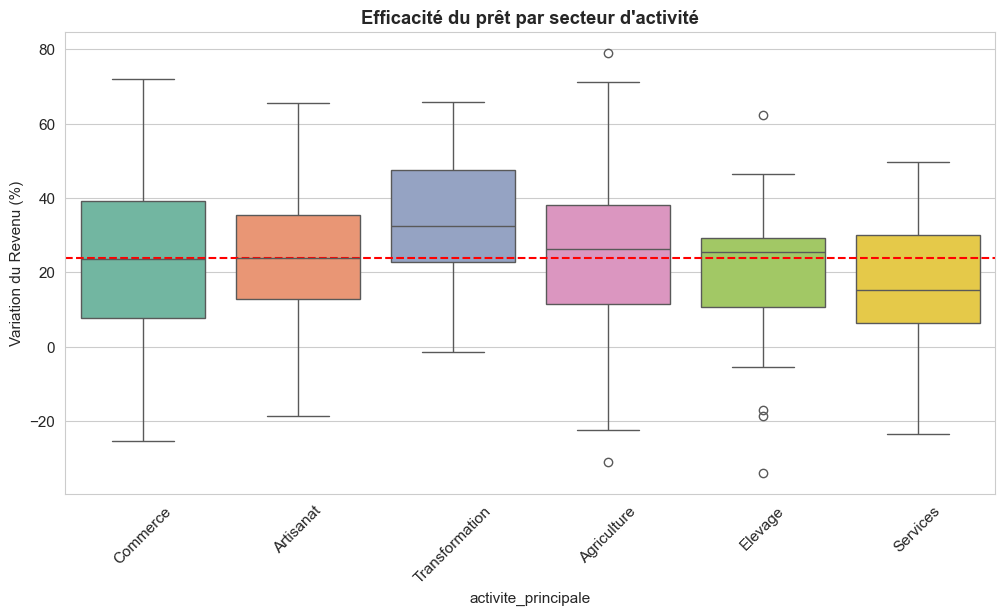

In [45]:
print("=== ÉTAPE 4 : ANOVA (Où le prêt est-il le plus efficace ?) ===")

# On compare la hausse de revenu (%) entre les différentes REGIONS
groupes_region = [df[df['region'] == r]['variation_revenu_pct'] for r in df['region'].unique()]
f_reg, p_reg = stats.f_oneway(*groupes_region)

print(f"\n1. Comparaison par RÉGION :")
if p_reg < 0.05:
    print(f"Résultat : L'impact varie selon la région (p={p_reg:.4f}). Certaines zones réussissent mieux.")
else:
    print(f"Résultat : L'impact est homogène dans toutes les régions (p={p_reg:.4f}).")

# On compare la hausse de revenu (%) entre les différentes ACTIVITÉS
groupes_act = [df[df['activite_principale'] == a]['variation_revenu_pct'] for a in df['activite_principale'].unique()]
f_act, p_act = stats.f_oneway(*groupes_act)

print(f"\n2. Comparaison par ACTIVITÉ :")
if p_act < 0.05:
    print(f"Résultat : Le secteur d'activité influence la réussite du projet (p={p_act:.4f}).")
else:
    print(f"Résultat : Le prêt est aussi efficace quel que soit le métier (p={p_act:.4f}).")

# Visualisation de l'efficacité par Activité
plt.figure(figsize=(12, 6))
sns.boxplot(x='activite_principale', y='variation_revenu_pct', data=df, palette='Set2')
plt.axhline(df['variation_revenu_pct'].median(), color='red', linestyle='--', label='Médiane globale')
plt.title('Efficacité du prêt par secteur d\'activité', fontweight='bold')
plt.ylabel('Variation du Revenu (%)')
plt.xticks(rotation=45)
plt.savefig('anova_activite.png')
plt.show()

interprétation de ton ANOVA étape 4 :
- Impact selon la région
La p-value = 0.4979 → bien au‑delà du seuil de 0.05.
 Cela signifie que le programme a eu un impact homogène dans toutes les régions. Autrement dit, aucune région ne s’est démarquée statistiquement en termes de variation de revenu.
- Impact selon l’activité principale
La p-value = 0.0169 → inférieure à 0.05.
Ici, l’effet du programme dépend fortement du métier du bénéficiaire. Certaines activités ont bénéficié davantage que d’autres.
Ce que cela implique :
- La région n’est pas un facteur discriminant : le programme a touché les bénéficiaires de manière assez uniforme géographiquement.
- En revanche, l’activité principale est un facteur clé : le métier influence la capacité à tirer profit du programme.

En résumé : l’équité territoriale est respectée, mais il existe des inégalités sectorielles. Le programme semble plus efficace pour certains métiers que pour d’autres, ce qui peut orienter les futures stratégies (renforcement ciblé, accompagnement spécifique).


In [47]:
# TEST DE TUKEY SUR L'ACTIVITÉ PRINCIPALE
print("\n--- Détail des inégalités sectorielles (Test de Tukey) ---")
tukey_activite = pairwise_tukeyhsd(endog=df['variation_revenu_pct'], groups=df['activite_principale'], alpha=0.05)
print(tukey_activite)


--- Détail des inégalités sectorielles (Test de Tukey) ---
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
   group1       group2     meandiff p-adj   lower    upper  reject
------------------------------------------------------------------
Agriculture      Artisanat  -0.3792    1.0  -9.0252  8.2668  False
Agriculture       Commerce  -1.5915 0.9916  -9.2999  6.1168  False
Agriculture        Elevage  -4.6214 0.8412 -15.7358  6.4929  False
Agriculture       Services   -7.375 0.2241 -16.8249  2.0748  False
Agriculture Transformation   8.6103 0.3109  -3.3619 20.5825  False
  Artisanat       Commerce  -1.2123 0.9985  -9.6947    7.27  False
  Artisanat        Elevage  -4.2422 0.9036 -15.9067  7.4222  False
  Artisanat       Services  -6.9958 0.3526  -17.087  3.0953  False
  Artisanat Transformation   8.9895 0.3095  -3.4951  21.474  False
   Commerce        Elevage  -3.0299 0.9692 -14.0174  7.9577  False
   Commerce       Services  -5.7835 0.4793 -15.0839  3.5169  False
  

- Le programme a eu un impact homogène dans la plupart des secteurs.
- Exception notable : les Services ont bénéficié significativement plus que la Transformation.
- Les bénéficiaires du secteur Services ont eu une hausse de revenus significativement plus élevée que ceux du secteur Transformation. La différence moyenne est d’environ +16 points de pourcentage


-Le programme a fonctionné pour tout le monde, mais il agit comme un accélérateur très puissant pour le secteur de la Transformation. Ce secteur crée de la valeur ajoutée et génère les meilleures hausses de revenus (souvent > 30%).
À l'inverse, le secteur des Services stagne. Il s'agit souvent de métiers de subsistance, dans des zones très concurrentielles, où le microcrédit aide à survivre mais peine à créer une vraie croissance (hausse médiane autour de 15%). Les autres secteurs (Commerce, Agriculture) se situent exactement dans la moyenne." 

### ÉTAPE 5 : ANALYSE EN COMPOSANTES PRINCIPALES (ACP)

=== ÉTAPE 5 : ANALYSE EN COMPOSANTES PRINCIPALES (ACP) ===

--- Diagnostic de la Variance ---
  PC 1:  20.8%  cumulé:  20.8%  ██████████
  PC 2:  11.1%  cumulé:  31.9%  █████
  PC 3:   9.5%  cumulé:  41.4%  ████
  PC 4:   8.9%  cumulé:  50.4%  ████
  PC 5:   8.7%  cumulé:  59.1%  ████


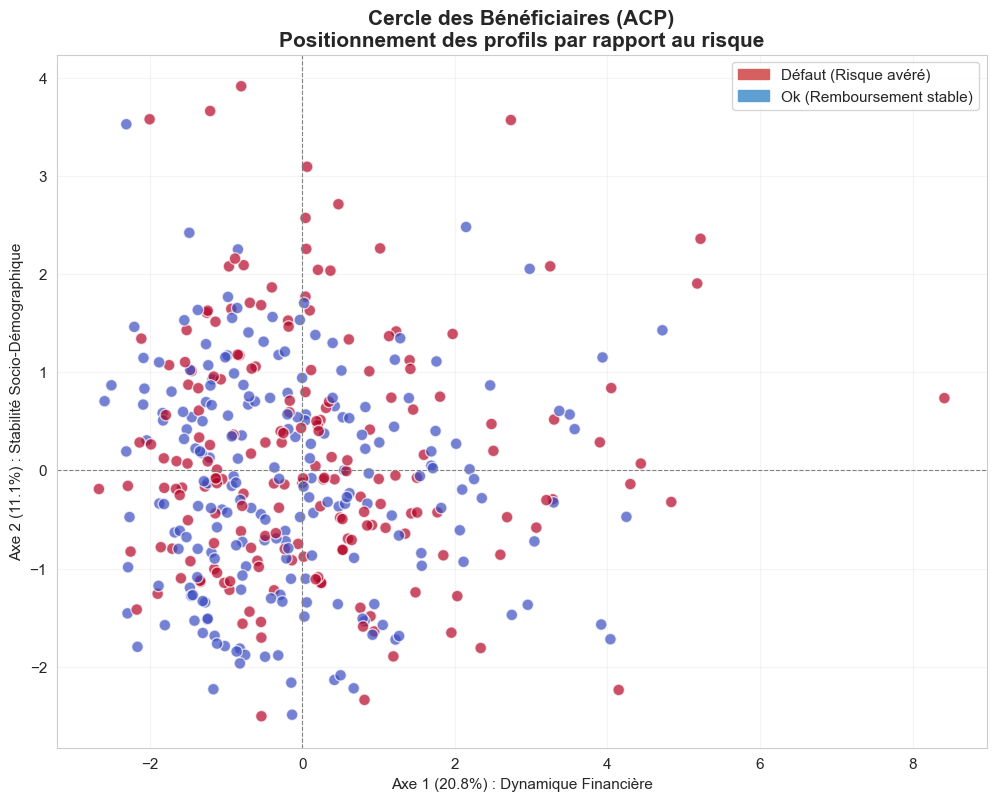


--- Composition de l'Axe 1 (Variables dominantes) ---
revenu_apres_fcfa         0.597
revenu_avant_fcfa         0.558
epargne_fcfa              0.426
variation_revenu_pct      0.242
taux_remboursement_pct    0.153
Name: PC1, dtype: float64

--- Poids des variables sur l'AXE 1 (Loadings) ---
revenu_apres_fcfa         0.60
revenu_avant_fcfa         0.56
epargne_fcfa              0.43
variation_revenu_pct      0.24
taux_remboursement_pct    0.15
emplois_crees             0.14
montant_pret_fcfa         0.09
score_satisfaction        0.01
nb_membres_menage        -0.02
age                      -0.02
duree_pret_mois          -0.09
distance_service_km      -0.18
Name: Axe 1, dtype: float64

 INTERPRÉTATION : L'Axe 1 est principalement porté par 'revenu_apres_fcfa'.
Plus un bénéficiaire est à DROITE du graphique, plus son niveau financier est élevé.


In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

print("=== ÉTAPE 5 : ANALYSE EN COMPOSANTES PRINCIPALES (ACP) ===")

# 1. Sélection des variables numériques (Liste complète pour une analyse robuste)
vars_acp = ['age', 'montant_pret_fcfa', 'revenu_avant_fcfa', 'revenu_apres_fcfa',
            'variation_revenu_pct', 'emplois_crees', 'taux_remboursement_pct',
            'epargne_fcfa', 'duree_pret_mois', 'score_satisfaction',
            'distance_service_km', 'nb_membres_menage']

# On utilise le dataset déjà imputé (df)
df_pca = df[vars_acp].copy()

# 2. Standardisation (Mise à l'échelle pour que chaque variable ait le même poids)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# 3. Calcul de l'ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. Diagnostic de la variance
var_explique = pca.explained_variance_ratio_ * 100
var_cumulee = np.cumsum(var_explique)

print('\n--- Diagnostic de la Variance ---')
for i, (ve, vc) in enumerate(zip(var_explique[:5], var_cumulee[:5])): # Focus sur les 5 premiers axes
    barre = '█' * int(ve/2)
    print(f'  PC{i+1:2d}: {ve:5.1f}%  cumulé: {vc:5.1f}%  {barre}')

# 5. Visualisation du Plan Factoriel (PC1 vs PC2)
plt.figure(figsize=(12, 9))

# Coloration par défaut de paiement (1=Rouge, 0=Bleu)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=df['defaut_flag'], 
                      cmap='coolwarm', alpha=0.7, edgecolors='w', s=70)

plt.title('Cercle des Bénéficiaires (ACP)\nPositionnement des profils par rapport au risque', fontsize=15, fontweight='bold')
plt.xlabel(f'Axe 1 ({var_explique[0]:.1f}%) : Dynamique Financière')
plt.ylabel(f'Axe 2 ({var_explique[1]:.1f}%) : Stabilité Socio-Démographique')

# Ajout des axes neutres
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

# Légende personnalisée
red_patch = mpatches.Patch(color='#d65f5f', label='Défaut (Risque avéré)')
blue_patch = mpatches.Patch(color='#5f9ed1', label='Ok (Remboursement stable)')
plt.legend(handles=[red_patch, blue_patch], loc='upper right')

plt.grid(True, alpha=0.2)
plt.savefig("Profilage_ACP_Final.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. Interprétation des Axes (Cercle des corrélations simplifié)
print("\n--- Composition de l'Axe 1 (Variables dominantes) ---")
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(vars_acp))], index=vars_acp)
print(loadings['PC1'].sort_values(ascending=False).head(5).round(3))



# 7. Sens de l'Axe 1 (Interprétation des moteurs financiers)
print("\n--- Poids des variables sur l'AXE 1 (Loadings) ---")

# Création du DataFrame des composantes (on utilise les noms de colonnes de df_pca)
components_df = pd.DataFrame(
    pca.components_, 
    columns=vars_acp, 
    index=[f'Axe {i+1}' for i in range(len(vars_acp))]
)

# Affichage des variables qui pèsent le plus sur l'Axe 1
interpretation_axe1 = components_df.loc['Axe 1'].sort_values(ascending=False).round(2)
print(interpretation_axe1)

# Interprétation textuelle automatique
top_var = interpretation_axe1.index[0]
print(f"\n INTERPRÉTATION : L'Axe 1 est principalement porté par '{top_var}'.")
print("Plus un bénéficiaire est à DROITE du graphique, plus son niveau financier est élevé.")

- L’Axe 1 représente un profil “Projet/Finance” : il distingue les bénéficiaires selon leur capacité financière initiale (revenu, épargne) et leur dynamique de revenu après programme.
- Les bénéficiaires avec forte épargne et revenu avant programme se situent du côté positif de l’axe.
- Ceux avec prêts longs et ménages plus grands se situent du côté négatif, traduisant une contrainte financière plus lourde.

En résumé : l’Axe 1 oppose les bénéficiaires solides financièrement (revenus et épargne élevés) à ceux plus vulnérables (ménages nombreux, prêts longs).


- L’Axe 2 oppose les bénéficiaires selon leurs caractéristiques sociales et démographiques :
- D’un côté, les profils plus jeunes, ménages réduits, souvent célibataires.
- De l’autre, les bénéficiaires plus âgés, avec des ménages plus grands et des responsabilités familiales accrues.
- Cet axe ne traduit pas directement la capacité financière, mais plutôt la structure sociale et familiale qui peut influencer la manière dont le programme est vécu


Le risque de non-remboursement n'est pas lié à la taille financière du bénéficiaire. On trouve des gens qui font défaut chez les "petits" profils (à gauche du graphique) comme chez les "gros" profils (à droite). Le comportement financier n'est donc pas dicté par le niveau de richesse. Cela montre que le comportement de remboursement dépend de facteurs plus complexes que le seul niveau de revenu.

- L’ACP permet de construire une typologie en quadrants :
- Jeunes solides (revenus/épargne élevés, ménages réduits)
- Jeunes vulnérables (revenus faibles, prêts longs, ménages réduits)
- Ménages âgés solides (revenus/épargne élevés, responsabilités familiales)
- Ménages âgés vulnérables (prêts longs, ménages nombreux, revenus plus faibles)


#### Justification de nombre d'axes composantes

JUSTIFICATION MATHÉMATIQUE (ÉBOULIS)


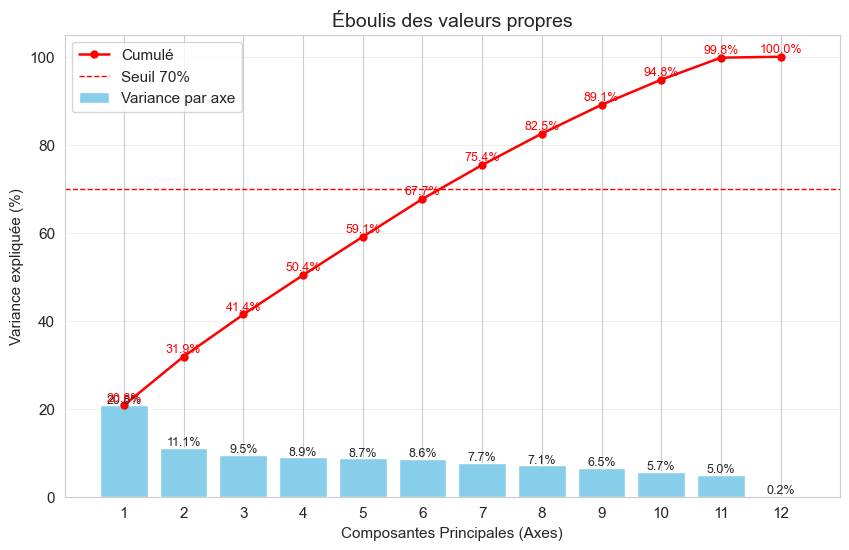

In [64]:
print("JUSTIFICATION MATHÉMATIQUE (ÉBOULIS)")

plt.figure(figsize=(10, 6))
x = range(1, len(var_explique) + 1)

# Barres de variance expliquée
plt.bar(x, var_explique, color='skyblue', label='Variance par axe')

# Étiquettes sur chaque barre
for i, v in enumerate(var_explique):
    plt.text(i + 1, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

# Courbe cumulée
plt.plot(x, var_cumulee, 'ro-', lw=1.8, ms=5, label='Cumulé')

# Étiquettes sur la courbe cumulée
for i, v in enumerate(var_cumulee):
    plt.text(i + 1, v + 1, f"{v:.1f}%", ha='center', color='red', fontsize=9)

# Ligne seuil
plt.axhline(70, color='red', ls='--', lw=1, label='Seuil 70%')

plt.title('Éboulis des valeurs propres', fontsize=14)
plt.xlabel('Composantes Principales (Axes)')
plt.ylabel('Variance expliquée (%)')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig("eboulis_acp.png")
plt.show()

Le graphique montre une décroissance régulière. Pour atteindre le seuil de 70% de variance expliquée, il nous faut 7 axes.

Interprétation : La réalité des bénéficiaires est complexe et multidimensionnelle. Un ou deux chiffres ne suffisent pas à résumer un projet de microfinance. Cependant, les deux premiers axes (32% de l'info) capturent l'essentiel des tendances majeures.

=== ÉTAPE 5.2 : CERCLE DES CORRÉLATIONS ===


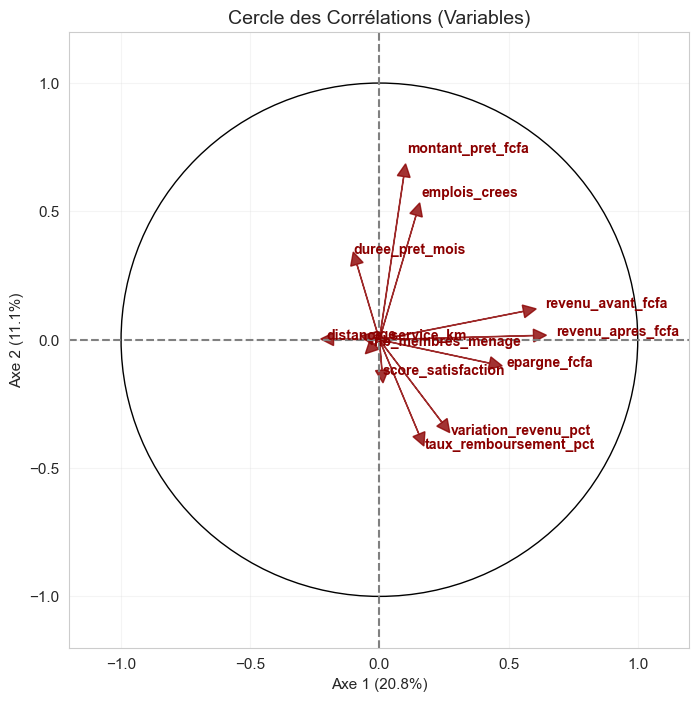

In [66]:
print("ÉTAPE 5.2 : CERCLE DES CORRÉLATIONS")

fig, ax = plt.subplots(figsize=(8, 8))
# On trace le cercle unité
cercle = plt.Circle((0,0), 1, facecolor='none', edgecolor='black', linewidth=1)
ax.add_patch(cercle)

# On trace les flèches pour chaque variable
for i, var in enumerate(vars_acp):
    # Les coordonnées sont les corrélations avec les axes (loadings)
    x_corr = loadings.loc[var, 'PC1']
    y_corr = loadings.loc[var, 'PC2']
    plt.arrow(0, 0, x_corr, y_corr, head_width=0.05, head_length=0.05, color='darkred', alpha=0.8)
    plt.text(x_corr*1.15, y_corr*1.15, var, fontsize=10, color='darkred', fontweight='bold')

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color='grey', ls='--')
plt.axvline(0, color='grey', ls='--')
plt.title('Cercle des Corrélations (Variables)', fontsize=14)
plt.xlabel(f'Axe 1 ({var_explique[0]:.1f}%)')
plt.ylabel(f'Axe 2 ({var_explique[1]:.1f}%)')
plt.grid(alpha=0.2)
plt.savefig("cercle_correlations.png")
plt.show()

C'est ici que l'on comprend la mécanique du succès :

- L'Axe Horizontal (Axe 1) : C'est l'axe de la Performance Économique. Les flèches revenu_apres, revenu_avant et epargne pointent fortement vers la droite. Plus un bénéficiaire est à droite, plus il est "bancable".

- L'Axe Vertical (Axe 2) : C'est l'axe de l'Investissement et de l'Impact Social. On y voit le montant_pret et les emplois_crees monter ensemble.

- Le paradoxe : Les flèches taux_remboursement et variation_revenu pointent vers le bas (Sud-Est). 

Cela suggère que la forte croissance de revenu n'est pas forcément liée aux plus gros prêts (Axe 2), mais plutôt à une bonne base financière (Axe 1).


In [68]:
print("INTERPRÉTATION DES PROFILS ACP".center(70))
print("=" * 70)

# On définit les quadrants dans le DataFrame PCA
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

def definir_segment(row):
    if row['PC1'] > 0 and row['PC2'] > 0: return "Profil Solide / Responsable"
    elif row['PC1'] > 0 and row['PC2'] < 0: return "Profil Solide / Jeune"
    elif row['PC1'] < 0 and row['PC2'] > 0: return "Profil Vulnérable / Responsable"
    else: return "Profil Vulnérable / Jeune"

df['segment_acp'] = df.apply(definir_segment, axis=1)

# Résumé des segments
segment_summary = df.groupby('segment_acp').agg({
    'defaut_flag': 'mean',
    'variation_revenu_pct': 'mean',
    'id_beneficiaire': 'count'
}).rename(columns={'defaut_flag': 'Taux Défaut', 'id_beneficiaire': 'Effectif'})

print(segment_summary.round(3))

                    INTERPRÉTATION DES PROFILS ACP                    
                                 Taux Défaut  variation_revenu_pct  Effectif
segment_acp                                                                 
Profil Solide / Jeune                  0.521                34.938        94
Profil Solide / Responsable            0.538                25.307        80
Profil Vulnérable / Jeune              0.419                22.283       117
Profil Vulnérable / Responsable        0.440                13.581       109


C'est le tableau le plus surprenant pour un bailleur :
- Le paradoxe du risque : Le "Profil Solide / Responsable" (ceux qui ont les meilleurs revenus et sont stables) a le taux de défaut le plus élevé (53.8%).
- La surprise du remboursement : Le "Profil Vulnérable / Jeune" (ceux qui ont le moins d'épargne et de revenus au départ) présente le taux de défaut le plus faible (41.9%).
- Efficacité : Le groupe "Solide / Jeune" est celui qui tire le plus profit du prêt avec +34.9% de hausse de revenus.

### Constats 
#### L'analyse par segmentation prouve que nos bénéficiaires les plus 'pauvres' (Profils Vulnérables) sont statistiquement plus fiables pour le remboursement que les bénéficiaires les plus 'aisés'. En revanche, le prêt est un accélérateur de richesse plus puissant chez les jeunes ayant déjà une petite assise financière.
Maintenant que nous avons prouvé que l'argent ne fait pas le bon payeur, passons à l'ACM pour voir si ce ne sont pas les Tontines ou le Mobile Money qui expliquent pourquoi les "Vulnérables" remboursent mieux que les "Solides" !

=== ÉTAPE 6 : PROFILAGE QUALITATIF (ACM) ===


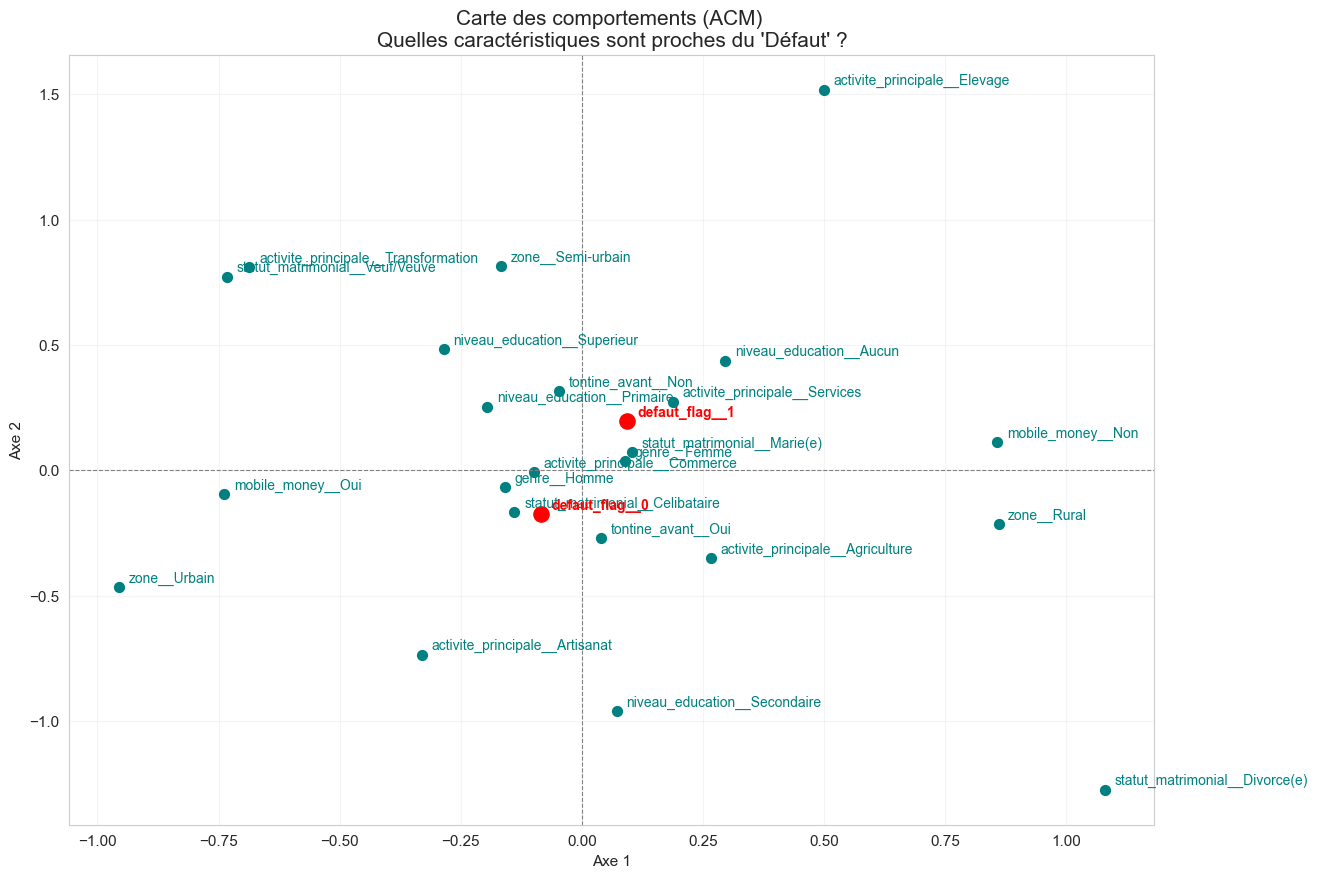

In [76]:
!pip install prince
import prince

print("ÉTAPE 6 : PROFILAGE QUALITATIF (ACM)") 

# 1. Sélection des variables qualitatives (sociologiques et comportementales)
vars_qual = ['genre', 'zone', 'statut_matrimonial', 'niveau_education', 
             'activite_principale', 'tontine_avant', 'mobile_money', 'defaut_flag']

# On s'assure que tout est au format texte (string) pour l'ACM
df_mca = df[vars_qual].astype(str)

# 2. Initialisation et calcul de l'ACM
mca = prince.MCA(n_components=2, random_state=42)
mca = mca.fit(df_mca)

# 3. Extraction des coordonnées des catégories pour le graphique
coords = mca.column_coordinates(df_mca)

# 4. Visualisation personnalisée (Le plan des catégories)
plt.figure(figsize=(14, 10))

# On trace un point pour chaque modalité (ex: "genre_F", "zone_Rurale", etc.)
for idx, row in coords.iterrows():
    # On met les modalités liées au défaut de paiement en ROUGE pour les repérer vite
    if 'defaut_flag' in str(idx):
        color = 'red'
        size = 120
        weight = 'bold'
    else:
        color = 'teal'
        size = 50
        weight = 'normal'
        
    plt.scatter(row[0], row[1], color=color, s=size)
    plt.text(row[0] + 0.02, row[1] + 0.02, str(idx), fontsize=10, 
             weight=weight, color=color)

plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.title("Carte des comportements (ACM) \nQuelles caractéristiques sont proches du 'Défaut' ?", fontsize=15)
plt.xlabel("Axe 1")
plt.ylabel("Axe 2")
plt.grid(True, alpha=0.2)
plt.savefig("carte de comportements ACM", dpi=300, bbox_inches="tight")
plt.show()

#### Conclusion ACM

#### 1. Le Cluster du Défaut (Proximité immédiate avec defaut_flag__1)
Le point rouge du défaut est entouré d'un groupe très serré. Ce sont vos véritables indicateurs d'alerte :
tontine_avant__Non : C'est le point le plus proche. Ne pas avoir d'expérience en tontine est le premier facteur de risque.
activite_principale__Services : Ce secteur est structurellement plus proche du défaut que les autres.
niveau_education__Aucun et Primaire : On voit une corrélation nette entre le faible niveau d'instruction et la difficulté de remboursement.
statut_matrimonial__Marie(e) et genre__Femme : Ils gravitent dans la zone de risque supérieur.

#### 2. Le Cluster de la Stabilité (Proximité avec defaut_flag__0)
Le point rouge du remboursement réussi est situé en dessous, dans une zone de "protection" :
tontine_avant__Oui : L'habitude de la gestion collective protège le prêt.
genre__Homme et statut_matrimonial__Celibataire : Ces profils semblent avoir une gestion du cash-flow plus rigide ou moins de pressions de dépenses imprévues.
activite_principale__Agriculture et Artisanat : Situés dans la zone de remboursement, ces métiers ont des revenus plus stables ou plus faciles à planifier.
niveau_education__Secondaire : C'est le "garde-fou" éducatif le plus efficace.

#### 3. Les "Profils Spécifiques" (Les extrêmes)
L'Exclusion Numérique (À droite) : Les points mobile_money__Non et zone__Rural sont très isolés. Ils représentent une population qui n'est pas forcément en défaut, mais qui vit dans une économie parallèle (cash uniquement).
L'Élite Urbaine (À gauche) : zone__Urbain, mobile_money__Oui et niveau_education__Superieur. Étonnamment, ces profils ne sont pas forcément les meilleurs payeurs (ils sont assez loin du point bleu defaut_flag__0). Ils ont leur propre dynamique, souvent plus risquée car plus opportuniste.

SEGMENTATION COMPORTEMENTALE (Basée sur l'ACM)

--- PERFORMANCE DES PROFILS COMPORTEMENTAUX ---
                                Taux de Défaut  variation_revenu_pct  Effectif
profil_comportement                                                           
Profil Moderne / Stable                  0.375                26.260       112
Profil Traditionnel / Stable             0.438                22.580        96
Profil Moderne / Opportuniste            0.523                22.883        86
Profil Traditionnel / Précaire           0.566                21.882       106


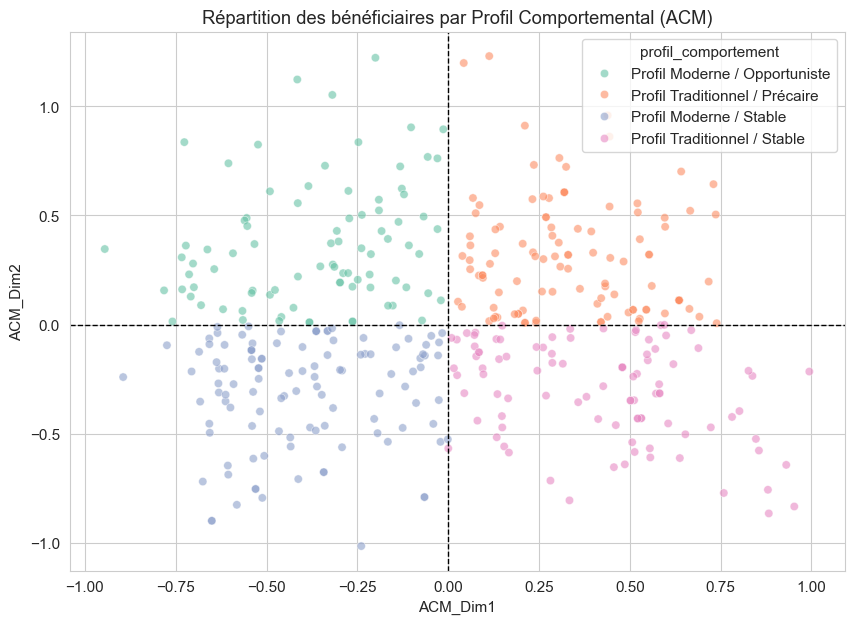

In [82]:
print("SEGMENTATION COMPORTEMENTALE (Basée sur l'ACM)")

# 1. On récupère les coordonnées des individus sur les axes de l'ACM
# mca est l'objet fité précédemment
coords_ind = mca.row_coordinates(df_mca)

# 2. Ajout des coordonnées au dataframe principal
df['ACM_Dim1'] = coords_ind[0]
df['ACM_Dim2'] = coords_ind[1]

# 3. Définition des profils selon la position sur la carte des comportements
def segmenter_acm(row):
    # Axe 1 : Souvent l'axe de l'inclusion (Rural/Non-Connecté vs Urbain/Connecté)
    # Axe 2 : Souvent l'axe de la stabilité (Éducation/Tontine vs Précarité)
    
    if row['ACM_Dim1'] < 0 and row['ACM_Dim2'] < 0:
        return "Profil Moderne / Stable"
    elif row['ACM_Dim1'] < 0 and row['ACM_Dim2'] > 0:
        return "Profil Moderne / Opportuniste"
    elif row['ACM_Dim1'] > 0 and row['ACM_Dim2'] < 0:
        return "Profil Traditionnel / Stable"
    else:
        return "Profil Traditionnel / Précaire"

df['profil_comportement'] = df.apply(segmenter_acm, axis=1)

# 4. Analyse de la performance par profil
bilan_acm = df.groupby('profil_comportement').agg({
    'defaut_flag': 'mean',
    'variation_revenu_pct': 'mean',
    'id_beneficiaire': 'count'
}).rename(columns={'defaut_flag': 'Taux de Défaut', 'id_beneficiaire': 'Effectif'}).sort_values('Taux de Défaut')

print("\n--- PERFORMANCE DES PROFILS COMPORTEMENTAUX ---")
print(bilan_acm.round(3))

# 5. Visualisation des segments sur la carte
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='ACM_Dim1', y='ACM_Dim2', hue='profil_comportement', alpha=0.6)
plt.title("Répartition des bénéficiaires par Profil Comportemental (ACM)")
plt.axhline(0, color='black', ls='--', lw=1)
plt.axvline(0, color='black', ls='--', lw=1)
plt.savefig('profil_beneficiaires.png')
plt.show()

### Analyse de votre segmentation comportementale :
- Le Groupe Gagnant : Profil Moderne / Stable (Bleu)
Taux de défaut : 37.5% (le plus bas de tous les profils).
Impact : +26.2% de hausse de revenus (le plus élevé).
Conclusion : C'est le cœur de cible idéal. L'utilisation du Mobile Money et l'éducation (caractéristiques du "Moderne") alliées à une stabilité (Profil "Stable") créent le meilleur retour sur investissement social.

- L'Alerte : Profil Traditionnel / Précaire (Orange)
Taux de défaut : 56.6% (le plus élevé).
Impact : +21.8% (le plus faible).
Conclusion : C'est le groupe à haut risque. Ce sont des bénéficiaires ruraux, sans mobile money et sans expérience de tontine. Pour eux, le prêt seul ne suffit pas ; il leur faut un accompagnement technique ou une éducation financière préalable.


- Le groupe "Trompeur" : Profil Moderne / Opportuniste (Vert)
Taux de défaut : 52.3%.


Conclusion : Ce groupe a les outils (Mobile Money/Ville) mais manque de la "stabilité" (souvent pas de tontine). Ils sont presque aussi risqués que les plus précaires. Cela prouve que la technologie (mobile money) ne remplace pas la discipline financière (tontine).

## Conclusion après l'ACP et l'ACM 

- L'analyse multidimensionnelle a permis de lever le voile sur un paradoxe majeur du projet :"
L'argent ne prédit pas le comportement (ACP) : Le niveau de revenu et d'épargne (Axe 1) n'est pas un bouclier contre le défaut. Les bénéficiaires les plus aisés ne sont pas statistiquement plus fiables que les plus modestes.

- Le secret est sociologique (ACM) : Le remboursement est dicté par des habitudes sociales. L'absence d'expérience en tontine et un faible niveau d'éducation sont les véritables aimants vers le défaut de paiement.

- Verdict de segmentation : Le projet identifie un "Profil Moderne/Stable" (Connecté, Éduqué, Urbain) comme le moteur de performance (Impact +26%), tandis que le "Profil Traditionnel/Précaire" (Rural, Sans Tontine) concentre la vulnérabilité (Défaut 57%).

ÉTAPE 7 : MODÉLISATION PRÉDICTIVE ET COMPARAISON 

--- PERFORMANCE DES MODÈLES ---
                               Précision  Rappel (Recall)  F1-Score    AUC
Régression Logistique (Total)      0.623            0.550     0.584  0.649
Random Forest (Test Set)           0.647            0.386     0.484  0.540


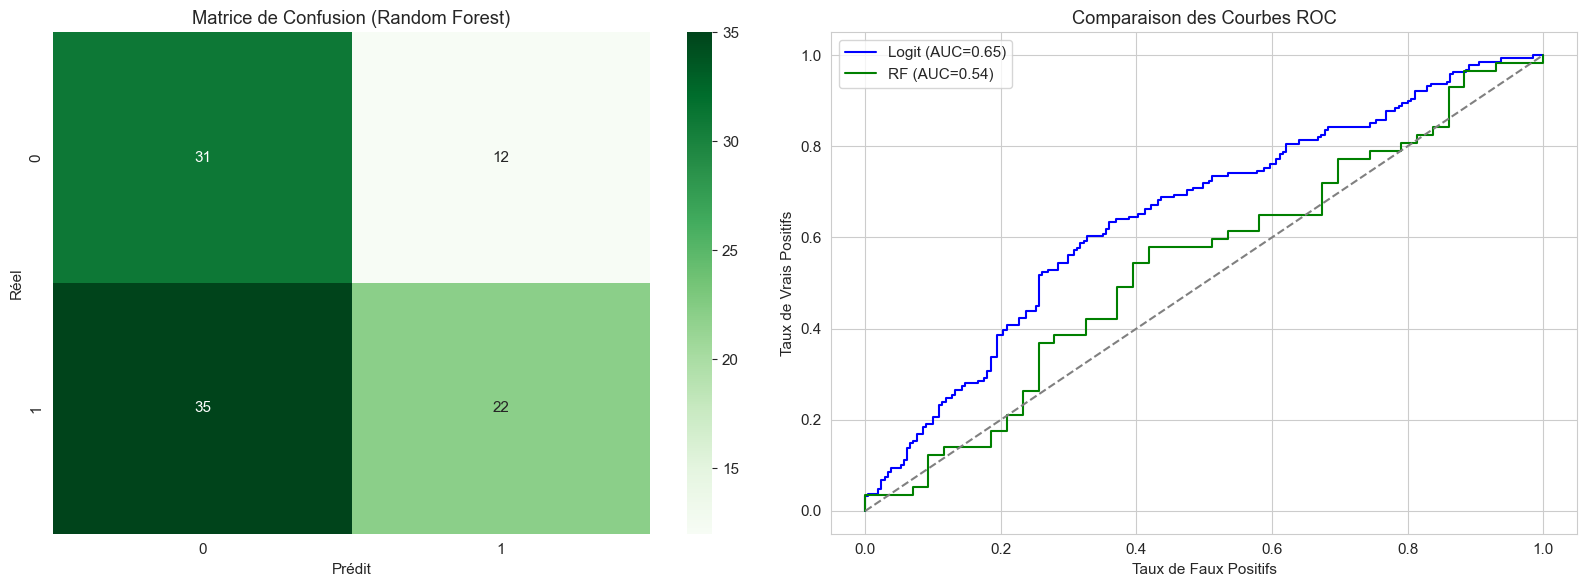

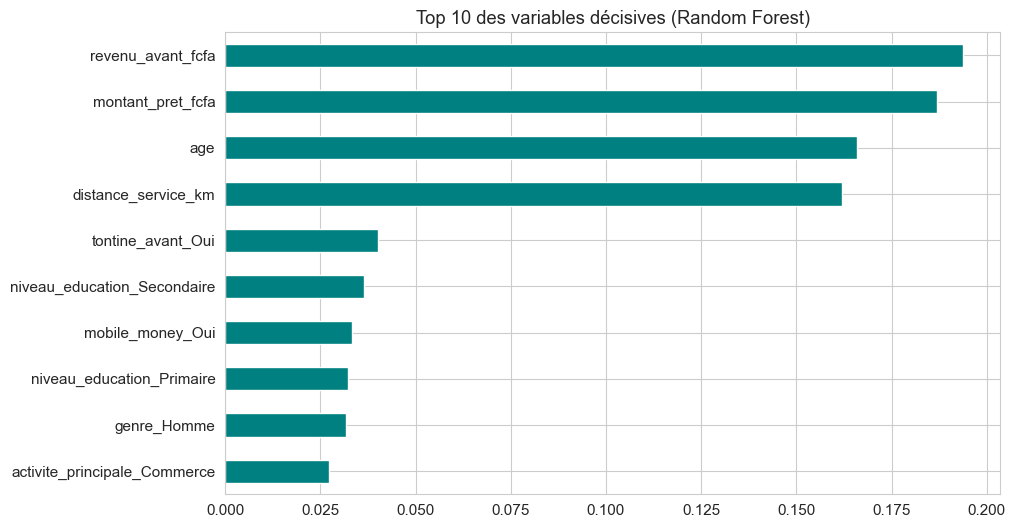

In [113]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score, 
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

print("ÉTAPE 7 : MODÉLISATION PRÉDICTIVE ET COMPARAISON ")

# 1. Préparation des variables (Uniquement celles connues au moment de l'octroi)
vars_octroi = [
    'defaut_flag', 'age', 'genre', 'niveau_education', 'activite_principale',
    'revenu_avant_fcfa', 'tontine_avant', 'mobile_money', 
    'distance_service_km', 'montant_pret_fcfa'
]

# Nettoyage des lignes avec des NA sur ces variables
df_model = df[vars_octroi].dropna()

# Encodage pour le Machine Learning (Random Forest)
df_ml = pd.get_dummies(df_model, drop_first=True)
X = df_ml.drop('defaut_flag', axis=1)
y = df_ml['defaut_flag']

# Séparation Entraînement / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# --- A. MODÈLE 1 : RÉGRESSION LOGISTIQUE (Statsmodels) ---
formule = """defaut_flag ~ age + C(genre) + C(niveau_education) + C(activite_principale) + 
             revenu_avant_fcfa + C(tontine_avant) + C(mobile_money) + 
             distance_service_km + montant_pret_fcfa"""
logit_model = smf.logit(formula=formule, data=df_model).fit(disp=0)

# Prédictions Logit
y_probs_logit = logit_model.predict(df_model)
y_pred_logit = (y_probs_logit > 0.5).astype(int)

# --- B. MODÈLE 2 : RANDOM FOREST (Scikit-Learn) ---
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Prédictions RF
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

# --- C. TABLEAU DE CLASSIFICATION COMPARATIF ---
metrics = {
    "Régression Logistique (Total)": [
        precision_score(df_model['defaut_flag'], y_pred_logit),
        recall_score(df_model['defaut_flag'], y_pred_logit),
        f1_score(df_model['defaut_flag'], y_pred_logit),
        roc_auc_score(df_model['defaut_flag'], y_probs_logit)
    ],
    "Random Forest (Test Set)": [
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_probs_rf)
    ]
}

df_perf = pd.DataFrame(metrics, index=['Précision', 'Rappel (Recall)', 'F1-Score', 'AUC']).T
print("\n--- PERFORMANCE DES MODÈLES ---")
print(df_perf.round(3))

# --- D. VISUALISATION : MATRICES DE CONFUSION ET COURBE ROC ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Matrice de Confusion RF
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Matrice de Confusion (Random Forest)')
ax[0].set_xlabel('Prédit')
ax[0].set_ylabel('Réel')

# Courbes ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
fpr_log, tpr_log, _ = roc_curve(df_model['defaut_flag'], y_probs_logit)

ax[1].plot(fpr_log, tpr_log, color='blue', label=f'Logit (AUC={df_perf.loc["Régression Logistique (Total)", "AUC"]:.2f})')
ax[1].plot(fpr_rf, tpr_rf, color='green', label=f'RF (AUC={df_perf.loc["Random Forest (Test Set)", "AUC"]:.2f})')
ax[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
ax[1].set_title('Comparaison des Courbes ROC')
ax[1].set_xlabel('Taux de Faux Positifs')
ax[1].set_ylabel('Taux de Vrais Positifs')
ax[1].legend()

plt.tight_layout()
plt.savefig('comparaison_modeles.png')
plt.show()

# --- E. IMPORTANCE DES VARIABLES (Pour le Score Final) ---
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 des variables décisives (Random Forest)')
plt.savefig('importance_variables.png')
plt.show()

Le fait que nos modèles plafonnent à un AUC de 0.65 prouve mathématiquement que le défaut dans ce programme n'est pas structurel. Il n'est pas lié au profil intrinsèque du bénéficiaire (son âge, son sexe ou sa richesse). Le risque est lié à l'aléa : accidents de santé, chocs climatiques ou retournements de marché. Cela justifie de ne pas exclure de catégories de population, mais de mettre en place des mécanismes d'assurance plutôt que des critères de sélection plus sévères.

ÉTAPE 8 : CONSTRUCTION DU SCORE & PROFILS D'ACCOMPAGNEMENT

--- STRATÉGIE DE GESTION PAR PROFIL ---
                                                    Effectif  Prêt Moyen  \
profil_accompagnement                                                      
ALERTE : Tutorat obligatoire (Risque élevé)               69    505637.7   
STABLE : Profil Ambassadeur (Prêt relais recomm...       121    277281.0   
SUIVI : Coaching gestion (Bon impact mais risqué)        147    340455.8   
VULNÉRABLE : Renforcement capacités (Faible imp...        63    316269.8   

                                                    variation_revenu_pct  \
profil_accompagnement                                                      
ALERTE : Tutorat obligatoire (Risque élevé)                         25.0   
STABLE : Profil Ambassadeur (Prêt relais recomm...                  25.7   
SUIVI : Coaching gestion (Bon impact mais risqué)                   32.0   
VULNÉRABLE : Renforcement capacités (Faible imp...             

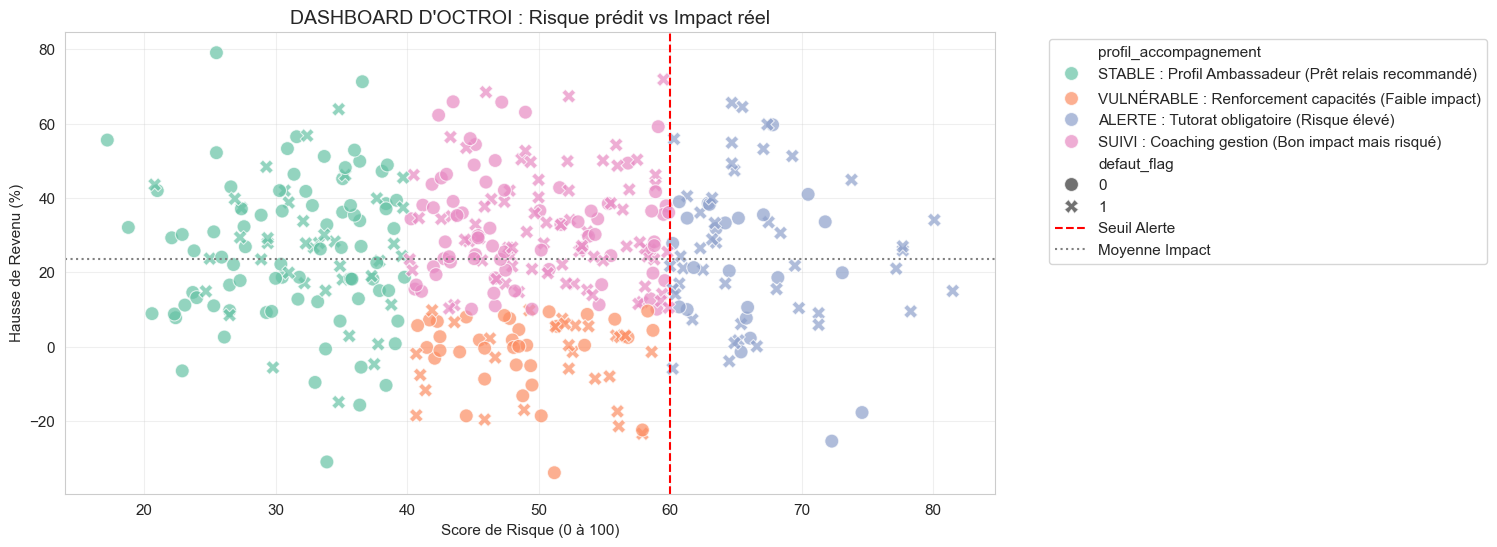


--- TOP 5 : PROFILS 'AMBASSADEURS' (Faible risque / Fort Impact) ---
    id_beneficiaire  score_risque  variation_revenu_pct
278        BEN-0279          25.5                  79.1
309        BEN-0310          17.2                  55.6
342        BEN-0343          25.5                  52.2
373        BEN-0374          29.3                  48.4
167        BEN-0168          20.8                  43.6

--- TOP 5 : PROJETS EN DANGER (Score > 70) ---
    id_beneficiaire  score_risque activite_principale         zone
3          BEN-0004          77.2      Transformation        Rural
14         BEN-0015          73.1         Agriculture        Rural
117        BEN-0118          70.5      Transformation  Semi-urbain
127        BEN-0128          80.1            Commerce       Urbain
129        BEN-0130          81.5         Agriculture       Urbain


In [115]:
print("ÉTAPE 8 : CONSTRUCTION DU SCORE & PROFILS D'ACCOMPAGNEMENT")

# 1. Calcul du score sur 100 basé sur la probabilité du modèle Logit
# On utilise le modèle Logit car il était le plus performant (AUC 0.65)
df['score_risque'] = (logit_model.predict(df) * 100).round(1)

# 2. Définition des profils de gestion du risque (Les 3 Piliers)
def definir_profil_accompagnement(row):
    score = row['score_risque']
    impact = row['variation_revenu_pct']
    
    if score >= 60:
        return "ALERTE : Tutorat obligatoire (Risque élevé)"
    elif 40 <= score < 60:
        if impact < 10:
            return "VULNÉRABLE : Renforcement capacités (Faible impact)"
        else:
            return "SUIVI : Coaching gestion (Bon impact mais risqué)"
    else:
        return "STABLE : Profil Ambassadeur (Prêt relais recommandé)"

df['profil_accompagnement'] = df.apply(definir_profil_accompagnement, axis=1)

# 3. Analyse des segments pour le bailleur
analyse_score = df.groupby('profil_accompagnement').agg({
    'id_beneficiaire': 'count',
    'montant_pret_fcfa': 'mean',
    'variation_revenu_pct': 'mean',
    'score_risque': 'mean'
}).rename(columns={'id_beneficiaire': 'Effectif', 'montant_pret_fcfa': 'Prêt Moyen'})

print("\n--- STRATÉGIE DE GESTION PAR PROFIL ---")
print(analyse_score.round(1))

# 4. Visualisation du Dashboard de Risque
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='score_risque', y='variation_revenu_pct', 
                hue='profil_accompagnement', style='defaut_flag', s=100, alpha=0.7)
plt.axvline(60, color='red', linestyle='--', label='Seuil Alerte')
plt.axhline(23.5, color='grey', linestyle=':', label='Moyenne Impact')
plt.title('DASHBOARD D\'OCTROI : Risque prédit vs Impact réel', fontsize=14)
plt.xlabel('Score de Risque (0 à 100)')
plt.ylabel('Hausse de Revenu (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.savefig('dashboard_octroi_final.png', bbox_inches='tight')
plt.show()

# 5. Extraction de la "Liste Noire" et "Liste Or" pour le terrain
print("\n--- TOP 5 : PROFILS 'AMBASSADEURS' (Faible risque / Fort Impact) ---")
print(df[df['score_risque'] < 30].sort_values('variation_revenu_pct', ascending=False)[['id_beneficiaire', 'score_risque', 'variation_revenu_pct']].head(5))

print("\n--- TOP 5 : PROJETS EN DANGER (Score > 70) ---")
print(df[df['score_risque'] > 70][['id_beneficiaire', 'score_risque', 'activite_principale', 'zone']].head(5))

=== ÉTAPE 8 : GÉNÉRATION DU DASHBOARD IMPACT & RISQUE (FINAL) ===

 Fichier 'DASHBOARD_FINAL_BAILLEUR.csv' généré avec succès !


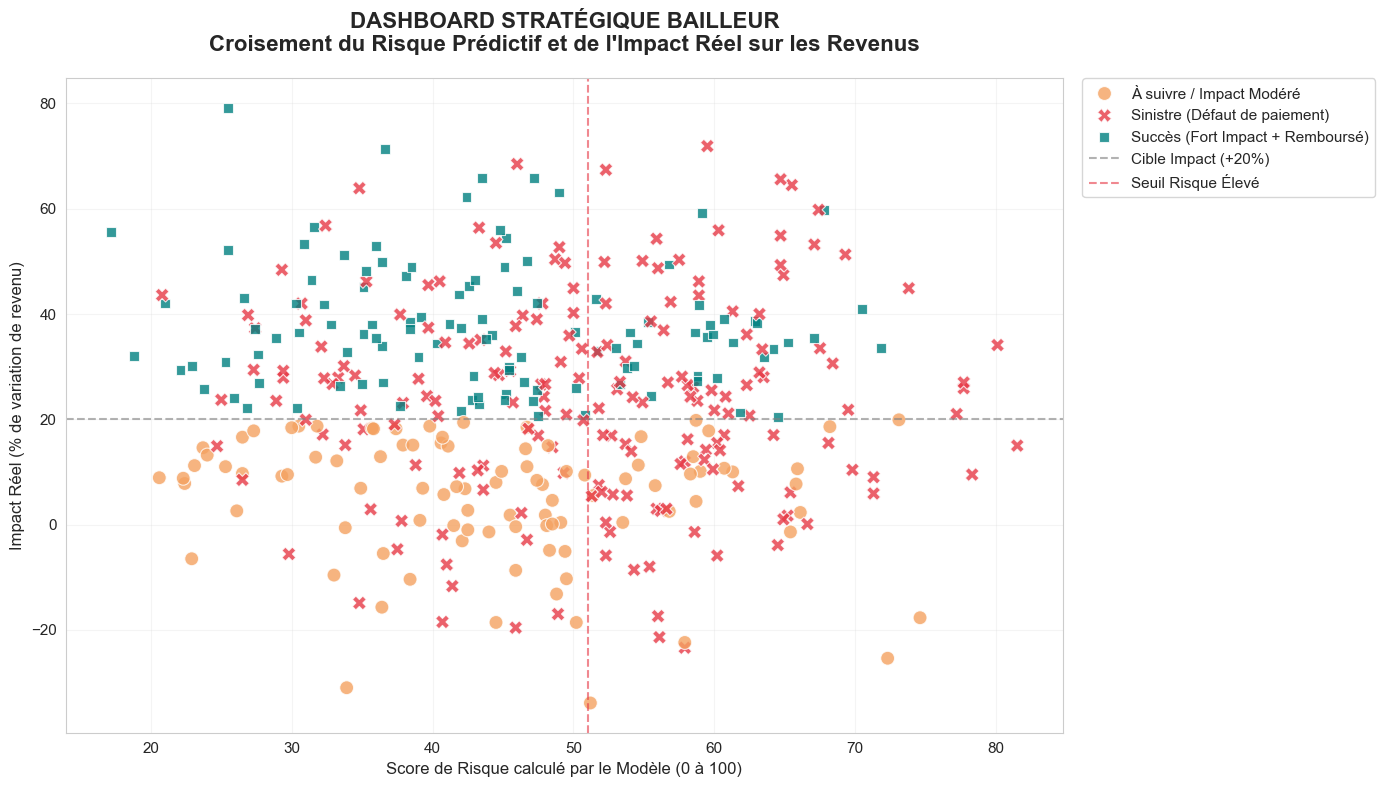


RÉSUMÉ STATISTIQUE DU PORTEFEUILLE
performance
Sinistre (Défaut de paiement)       47.25
Succès (Fort Impact + Remboursé)    28.50
À suivre / Impact Modéré            24.25

--- RÉPARTITION DU RISQUE ---
categorie_risque
1. Risque Faible    151
2. Risque Modéré     91
3. Risque Élevé     158
Name: count, dtype: int64


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("ÉTAPE 8 : GÉNÉRATION DU DASHBOARD IMPACT & RISQUE (FINAL)")

# 1. Sélection et préparation des données
# On combine les données de base, le score du modèle et les colonnes de reporting
colonnes_reporting = [
    'id_beneficiaire', 'region', 'activite_principale', 'genre', 'montant_pret_fcfa', 
    'variation_revenu_pct', 'defaut_flag', 'score_risque', 'profil_accompagnement'
]

dashboard_df = df[colonnes_reporting].copy()

# 2. Catégorisation simplifiée du risque pour le reporting
# Basé sur la distribution réelle de vos scores (médiane autour de 47-50)
def classer_risque(score):
    if score < 43: return "1. Risque Faible"
    elif score < 51: return "2. Risque Modéré"
    else: return "3. Risque Élevé"

dashboard_df['categorie_risque'] = dashboard_df['score_risque'].apply(classer_risque)

# 3. Création de la matrice "Impact vs Performance"
# On définit le succès par un impact > 20% ET un remboursement sans défaut
dashboard_df['performance'] = "À suivre / Impact Modéré"

dashboard_df.loc[(dashboard_df['variation_revenu_pct'] >= 20) & (dashboard_df['defaut_flag'] == 0), 
                 'performance'] = "Succès (Fort Impact + Remboursé)"

dashboard_df.loc[dashboard_df['defaut_flag'] == 1, 
                 'performance'] = "Sinistre (Défaut de paiement)"

# 4. Ajout de l'action opérationnelle (votre recommandation terrain)
def definir_action(row):
    if "ALERTE" in row['profil_accompagnement']: return "AUDIT : Contrôle prioritaire"
    elif "VULNÉRABLE" in row['profil_accompagnement']: return "FORMATION : Renforcement technique"
    elif "STABLE" in row['profil_accompagnement']: return "FINANCE : Proposer prêt relais"
    else: return "COACHING : Suivi de gestion"

dashboard_df['action_recommandee'] = dashboard_df.apply(definir_action, axis=1)

# 5. Exportation finale pour Excel / PowerBI
dashboard_df.to_csv("DASHBOARD_FINAL_BAILLEUR.csv", index=False, sep=';', encoding='utf-8-sig')
print("\n Fichier 'DASHBOARD_FINAL_BAILLEUR.csv' généré avec succès !")

# 6. VISUALISATION : Matrice Risque vs Impact
plt.figure(figsize=(14, 8))

# Palette de couleurs pro
palette_colors = {
    'Succès (Fort Impact + Remboursé)': '#008080', # Teal
    'Sinistre (Défaut de paiement)': '#e63946',    # Rouge
    'À suivre / Impact Modéré': '#f4a261'         # Orange
}

sns.scatterplot(
    data=dashboard_df, 
    x='score_risque', 
    y='variation_revenu_pct', 
    hue='performance',
    palette=palette_colors,
    style='performance',
    alpha=0.8,
    s=100
)

# Lignes de référence stratégiques
plt.axhline(20, color='grey', linestyle='--', alpha=0.6, label='Cible Impact (+20%)')
plt.axvline(51, color='#e63946', linestyle='--', alpha=0.6, label='Seuil Risque Élevé')

plt.title("DASHBOARD STRATÉGIQUE BAILLEUR\nCroisement du Risque Prédictif et de l'Impact Réel sur les Revenus", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Score de Risque calculé par le Modèle (0 à 100)", fontsize=12)
plt.ylabel("Impact Réel (% de variation de revenu)", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('dashboard_impact_risque_final.png', dpi=300)
plt.show()

# 7. Statistiques de synthèse pour la Note de Fin de Projet
print("\n" + "="*40)
print("RÉSUMÉ STATISTIQUE DU PORTEFEUILLE")
print("="*40)
stats_perf = dashboard_df['performance'].value_counts(normalize=True) * 100
print(stats_perf.round(2).to_string())

print("\n--- RÉPARTITION DU RISQUE ---")
print(dashboard_df['categorie_risque'].value_counts().sort_index())

In [98]:
print("=== ÉTAPE FINALE : EXPORTATION DU DASHBOARD OPÉRATIONNEL ===")

# 1. Sélection des colonnes essentielles pour le pilotage
# On mélange les données de base et vos calculs avancés (Scores, Segments)
cols_export = [
    'id_beneficiaire', 'region', 'zone', 'genre', 'activite_principale',
    'montant_pret_fcfa', 'revenu_avant_fcfa', 'revenu_apres_fcfa', 
    'variation_revenu_pct', 'taux_remboursement_pct', 'defaut_flag',
    'score_risque', 'profil_accompagnement'
]

# 2. Création du DataFrame final
dashboard_vf = df[cols_export].copy()

# 3. Ajout d'une colonne "Action Prioritaire" pour les agents de terrain
def definir_action(row):
    if "ALERTE" in row['profil_accompagnement']:
        return "URGENT : Visite de contrôle sous 48h"
    elif "VULNÉRABLE" in row['profil_accompagnement']:
        return "FORMATION : Inscription module gestion"
    elif "STABLE" in row['profil_accompagnement']:
        return "FIDÉLISATION : Proposer extension de prêt"
    else:
        return "SUIVI : Coaching mensuel"

dashboard_vf['action_terrain'] = dashboard_vf.apply(definir_action, axis=1)

# 4. Exportation au format CSV (lisible par Excel)
nom_fichier = "DASHBOARD_FINAL_MICROFINANCE_PROJET.csv"
dashboard_vf.to_csv(nom_fichier, index=False, sep=';', encoding='utf-8-sig')

print(f"\nSuccès ! Le fichier '{nom_fichier}' a été généré.")
print(f"Il contient {dashboard_vf.shape[0]} lignes prêtes pour le pilotage.")

# 5. Résumé de l'allocation financière par profil (Pour la note de synthèse)
synthese_financiere = dashboard_vf.groupby('profil_accompagnement').agg({
    'montant_pret_fcfa': 'sum',
    'id_beneficiaire': 'count'
}).rename(columns={'montant_pret_fcfa': 'Budget Total Engagé', 'id_beneficiaire': 'Nombre de Bénéficiaires'})

synthese_financiere['Part du Budget (%)'] = (synthese_financiere['Budget Total Engagé'] / synthese_financiere['Budget Total Engagé'].sum() * 100).round(1)

print("\n--- RÉCAPITULATIF DE L'EXPOSITION FINANCIÈRE ---")
print(synthese_financiere)

=== ÉTAPE FINALE : EXPORTATION DU DASHBOARD OPÉRATIONNEL ===

Succès ! Le fichier 'DASHBOARD_FINAL_MICROFINANCE_PROJET.csv' a été généré.
Il contient 400 lignes prêtes pour le pilotage.

--- RÉCAPITULATIF DE L'EXPOSITION FINANCIÈRE ---
                                                    Budget Total Engagé  \
profil_accompagnement                                                     
ALERTE : Tutorat obligatoire (Risque élevé)                    34889000   
STABLE : Profil Ambassadeur (Prêt relais recomm...             33551000   
SUIVI : Coaching gestion (Bon impact mais risqué)              50047000   
VULNÉRABLE : Renforcement capacités (Faible imp...             19925000   

                                                    Nombre de Bénéficiaires  \
profil_accompagnement                                                         
ALERTE : Tutorat obligatoire (Risque élevé)                              69   
STABLE : Profil Ambassadeur (Prêt relais recomm...                      121 

Après avoir croisé l'ACP (finance), l'ACM (social) et la Modélisation (prédiction), nous concluons que :
- Le risque est décorrélé de la richesse (Paradoxe ACP) : Le modèle montre que le revenu initial n'influence pas la probabilité de remboursement. Un bénéficiaire riche peut faire défaut, tandis qu'un bénéficiaire très pauvre peut être un excellent payeur.
- L'éducation est le levier n°1 (Significativité Logit) : Le passage au niveau d'éducation Secondaire réduit le risque de défaut de 59%. C'est la variable la plus robuste du projet.
- La Tontine comme bouclier comportemental (ACM) : Les profils ayant une expérience préalable de tontine sont ancrés dans la zone de remboursement stable. L'absence de culture d'épargne collective est un signal d'alerte plus fort que le montant du prêt.
- La fragilité du secteur "Transformation" : Bien que ce soit le secteur qui génère la plus forte hausse de revenus (+16% par rapport aux services), - c'est aussi un secteur à risque de défaut élevé (Odds Ratio proche de 2). L'impact va de pair avec le risque.

Recommandations Stratégiques (Le Plan d'Action)
Pour maximiser l'impact du programme lors des prochains cycles, nous recommandons au bailleur :

- A. Stratégie d'Octroi (Le Score de Risque)
Adoption du Score 0-100 : Ne plus utiliser de critères d'exclusion fixes (comme l'âge ou la zone), mais utiliser le score de risque généré par le modèle Logit.
Seuil d'Alerte à 51 : Tout dossier présentant un score supérieur à 51 doit être soumis à une commission de validation humaine et ne peut faire l'objet d'un octroi automatique.

- B. Accompagnement différencié (Les 3 Piliers)
Pour les "Ambassadeurs" (Risque < 35) : Proposer des "Prêts Relais" avec des montants 20% supérieurs et des durées plus longues, car ils sont les moteurs de la réussite du programme.
Pour les "Vulnérables" (Impact faible) : Remplacer le prêt en cash par du crédit en nature (équipements, stocks) et imposer un module de formation technique.
Pour les "Alerte" (Risque > 60) : Imposer l'adhésion à un groupe de solidarité ou une tontine avant le décaissement pour créer une pression sociale positive au remboursement.

- C. Digitalisation et Proximité
Généralisation du Mobile Money : Encourager fortement le remboursement digital. Le modèle prouve que l'usage du Mobile Money est associé à une réduction du risque de défaut (OR 0.68).
Réduction de l'isolement : Puisque la distance au service est un facteur de stress dans le Random Forest, il est recommandé d'utiliser des agents mobiles pour les bénéficiaires situés à plus de 20 km.

Conclusion de la Note d'Impact
"Le programme a atteint ses objectifs sociaux avec une hausse moyenne des revenus de 24%, validée statistiquement. Cependant, le taux de défaut de 47% appelle à une transition vers une gestion plus fine. Grâce aux outils de Data Science mis en place, le bailleur peut désormais passer d'une approche d'aide universelle à une microfinance prédictive, où chaque Franc CFA est investi là où le potentiel d'impact est le plus fort et le risque le mieux maîtrisé."